In this notebook, you will be guided through a complete, end-to-end workflow for **training, testing, evaluating, selecting the best model, and performing hyperparameter tuning** for time series forecasting. The goal is to provide a clean, repeatable, and extensible structure that both agents and data scientists can follow to build high-quality forecasting pipelines.

---

##  Dataset Overview

The dataset represents **monthly demand for hardware products**. Each row corresponds to one month of demand for a specific product. The key fields include:

* **`unique_id`** the identifier for each individual time series
* **`ds`** timestamp column at monthly granularity
* **`y`** the target variable representing monthly product demand
* 
* **Additional categorical and continuous features** used for global modeling:

  * `product_type`
  * `region`
  * `unit_cost`
  * `unit_installation_cost`
* ** profile_cluster variable
* profile_cluster is generated with the following rule: `profile_cluster` is equal to `profile` and where `profile` == 'regular' then it is substituted by the cluster value. Then both variables `profile` and `cluster` are removed from the dataframe
  * 

These features enable the model to capture cross-series patterns, shared seasonality, and product-level differences.

---

##  Modeling Framework

All forecasting models in this notebook are built using the **Nixtla forecasting ecosystem**:
[https://nixtlaverse.nixtla.io](https://nixtlaverse.nixtla.io)

Nixtla provides:

* Automated feature engineering
* Target transformations
* Global model interfaces
* Rolling-origin evaluation
* Hyperparameter optimization frameworks

The main model family used here is **LightGBM**, a fast gradient boosting tree model well-suited for large-scale global forecasting.

---
##  Model Variants and Training set Compared

We evaluate three LightGBM configurations to explore how different target transformations affect performance:

1. **Raw model** trained on the original untransformed demand
2. **Differenced model** trained on *first differences* to remove trend
3. **Standard scaled model** trained on demand normalized using a standard normal scaling transform

This comparison helps illustrate how transformation choices affect accuracy, stability, and stationarity.
This model variants are first trained as a global model on the whole training set and then trained again by profile_cluster. Results are compared. 

---
##  Adding features

Features are analyzed and grouped as:
- static, categorical, date and continuous
- group by what they represents based on the context provided by the data scientist(temperature data, calendar holidays, types of expenditure)
  
A table is proposed to the data scientist so that he/she can evaluate which features to include.

---

## Nixtla Transformation Capabilities

Nixtla supports a wide range of transformations, including automated and robust techniques commonly used in advanced forecasting pipelines.

Here are the **transformation names** you may consider:

```python
available_transformations = [
    "LocalStandardScaler",
    "LocalMinMaxScaler",
    "LocalRobustScaler (iqr)",
    "LocalRobustScaler (mad)",
    "LocalBoxCox",
    "Differences (1st diff)",
    "AutoDifferences",
    "AutoSeasonalDifferences",
    "AutoSeasonalityAndDifferences",
]
```

In addition to these built-in transforms, Nixtla allows you to define **custom transformation classes**, giving you complete flexibility for domain-specific preprocessing.

---
## Training by profile_cluster
The model variants are trained as a global model on the whole training set and then trained again by profile_cluster. Results are compared. 

## Rolling Evaluation to Avoid Data Leakage

All evaluation in this notebook is performed using **rolling-origin train-test splits**, ensuring that:

* Models never train on future data
* Each forecasting window simulates real operational forecasting
* Time-ordered leakage is avoided
* Model performance is stable across multiple backtests

This creates a realistic and leakage-free evaluation pipeline.

---

## Hyperparameter Tuning

After selecting the best model configuration (based on MAE in this example), we perform **hyperparameter tuning** using Nixtla automated search capabilities. This process can be easily adapted to:

* Different metrics (e.g., RMSE, MAPE, WAPE, quantile loss)
* Larger search spaces
* Different models (LightGBM, XGBoost, CatBoost, or neural models)

---

## Extending This Notebook

You can easily extend this entire workflow to **other model families**, such as:

* **XGBoost**
* **CatBoost**
* **ElasticNet / Linear models**
* **Deep learning models** (TFT, LSTM, DeepAR, NHITS, NBEATS, PatchTST, etc.)

To do so, simply:

1. Follow the same structure used in each block
2. Update the model definition
3. Adjust the transformation or hyperparameter tuning logic if needed

Each code block in this notebook begins with a description of:

* **What the block does**
* **Why it is necessary**
* **Important parameters and caveats**

This makes it simple and safe to adapt the pipeline while maintaining clarity and consistency.



# Implementation

## Load Packages and Configuration

Load the required packages. In Fabric, we use inline configuration instead of loading from external config files.

In [187]:
import os
from pathlib import Path

# Data elaboration functions
import numpy as np
import pandas as pd
from dateutil.relativedelta import relativedelta
import datetime
import holidays as h
from functools import reduce

# Nixtla / MLForecast
import mlflow
from mlforecast import MLForecast
from mlforecast.target_transforms import LocalStandardScaler, Differences
from mlforecast.auto import AutoLightGBM, AutoMLForecast, AutoModel

# LightGBM
from lightgbm import LGBMRegressor
import lightgbm as lgb

# Scikit-Learn
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Hyperparameter Optimization
import optuna

# Plots
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

# Spark for Fabric
from pyspark.sql import SparkSession

print("Packages loaded successfully!")

Packages loaded successfully!


# Setup

## Configuration Parameters

Defined inline for Fabric compatibility.

# ✅ CHECK POINT with the data scientist: set training start date and training end date

Plot up the target variable as the sum across all time series available, and then plot the target variable as the sum across all profile_cluster available.

These information are going to be useful for the training and predict step.

In [198]:
training_start_date = '2024-01-01'
training_end_date = '2025-01-06'
forecast_start_date = '2025-01-13'
forecast_end_date = '2025-05-20'

In [ ]:
# Time series configuration (inline - previously from config.yaml)
date_var = 'ds'
date_format = '%Y-%m-%d'
id = 'product_name'
unique_id = 'STORE_LOCATION_ID'
list_unique_id = [unique_id, date_var]
frequency = 'W-MON'
y = 'TOTAL_NET_SALES'
  
selection_metric = 'MAE'

# Fabric Lakehouse configuration
LAKEHOUSE_NAME = "ts_forecasting"

# Input table name
INPUT_TABLE_NAME = "df_final"

# Lakehouse table name for profile data
PROFILE_CLUSTER_TABLE_NAME = "df_profiling_clustering"

# Lakehouse table name for feature data
FEATURE_TABLE_NAME = "df_features"

root_path = Path.cwd().parent.parent

LOCAL_FOLDER = "supermarket_net_sales"  # Local folder for fallback storage

print(f"Configuration loaded:")
print(f"  - Date variable: {date_var}")
print(f"  - Target variable: {y}")
print(f"  - Unique ID: {unique_id}")
print(f"  - Frequency: {frequency}")
print(f"  - Prediction start date: {training_start_date}")
print(f"  - Prediction end date: {training_end_date}")
print("root_path: ", root_path)

Configuration loaded:
  - Date variable: ds
  - Target variable: TOTAL_NET_SALES
  - Unique ID: STORE_LOCATION_ID
  - Frequency: W-MON
  - Prediction start date: 2024-01-01
  - Prediction end date: 2025-01-06
root_path:  c:\Users\mabellani\OneDrive - Microsoft\Documents\REPOSITORY\time-series-forecasting-accelerator


# Load Data

## Load Feature Data from Lakehouse

Load the feature-engineered data from the Fabric Lakehouse table (previously saved from notebook 06 FeatureEngineering).

In [ ]:
# Load data from Lakehouse table
try:
    df = spark.read.table(f'{LAKEHOUSE_NAME}.{FEATURE_TABLE_NAME}').toPandas()
except:
    print("❌ Failed to load data from Lakehouse table. Loading from local parquet file.")
    df = pd.read_parquet(f"{root_path}/data/{LOCAL_FOLDER}/{FEATURE_TABLE_NAME}.parquet")
print(f"✅ Loaded {len(df)} rows")

df.head()

❌ Failed to load data from Lakehouse table. Loading from local parquet file.
✅ Loaded 4800 rows


,STORE_LOCATION_ID,ds,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,profile_cluster,lag1,lag2,rolling_mean_lag1_window_size3,rolling_std_lag1_window_size3,rolling_mean_lag2_window_size6,rolling_std_lag2_window_size6,year,month,week
0,1,2023-05-22,658506.242658,32653,2,0,1,1,0,0,...,1,683644.663227,669678.533134,656202.922622,36116.968510,615395.394403,49546.824149,2023,5,21
1,1,2023-05-29,653460.798201,32653,2,0,1,1,0,0,...,1,658506.242658,683644.663227,670609.813006,12595.058905,642200.363419,28461.222971,2023,5,22
2,1,2023-06-05,636980.378958,32653,2,0,1,1,0,0,...,1,653460.798201,658506.242658,665203.901362,16168.191026,648613.988548,26748.872726,2023,6,23
3,1,2023-06-12,668240.373924,32653,2,0,1,1,0,0,...,1,636980.378958,653460.798201,649649.139939,11257.764256,653655.829742,23677.441861,2023,6,24
4,1,2023-06-19,616229.163786,32653,2,0,1,1,0,0,...,1,668240.373924,636980.378958,652893.850361,15637.707432,652926.031280,24194.104414,2023,6,25


## Check dtypes

In [192]:
print("✅ Dtypes adjusted")
df.dtypes

✅ Dtypes adjusted


STORE_LOCATION_ID                          int64
ds                                datetime64[ns]
TOTAL_NET_SALES                          float64
STORE_SELLING_AREA_SQFT                    int64
NEARBY_COMPETITOR_STORE_COUNT              int64
COMPETITOR_PREMIUM_A_PRESENT               int64
COMPETITOR_DISCOUNT_A_PRESENT              int64
COMPETITOR_WAREHOUSE_A_PRESENT             int64
COMPETITOR_PREMIUM_B_PRESENT               int64
COMPETITOR_DISCOUNT_B_PRESENT              int64
HAS_COMPETITOR_IN_TRADE_AREA               int64
STORE_COUNT_IN_POSTAL_AREA                 int64
IS_SOLE_STORE_IN_POSTAL_AREA               int64
MARKET_SHARE_AREA_POSTAL                 float64
BASELINE_WEEKLY_SALES                    float64
STORE_ARCHETYPE                         category
REGION                                  category
profile_cluster                            int64
lag1                                     float64
lag2                                     float64
rolling_mean_lag1_wi

## Add profiling and clustering data and generate profile_cluster column with the following rule:
df_profile_cluster['profile_cluster'] = df_profile_cluster['profile']
df_profile_cluster.loc[df_profile_cluster['profile'] == 'regular', 'profile_cluster'] = df_profile_cluster['cluster']

In [ ]:
# Load data from Lakehouse table
if 'profile_cluster' not in df.columns:
    try:
        df_profile_cluster = spark.read.table(f'{LAKEHOUSE_NAME}.{PROFILE_CLUSTER_TABLE_NAME}').toPandas()
    except:
        print("Failed to load data from Lakehouse table. Loading from local parquet file.")
        df_profile_cluster = pd.read_parquet(f"{root_path}/data/{LOCAL_FOLDER}/{PROFILE_CLUSTER_TABLE_NAME.split('.')[-1]}.parquet")

    print(f"✅ Loaded {len(df_profile_cluster)} rows")

    # Merge df with df_cluster on the profile_cluster column
    df = df.merge(df_profile_cluster[['profile_cluster', unique_id]], on=unique_id, how='left')
else:
    print("profile_cluster column already exists in df, skipping merge.")
    
df.head()

profile_cluster column already exists in df, skipping merge.


,STORE_LOCATION_ID,ds,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,profile_cluster,lag1,lag2,rolling_mean_lag1_window_size3,rolling_std_lag1_window_size3,rolling_mean_lag2_window_size6,rolling_std_lag2_window_size6,year,month,week
0,1,2023-05-22,658506.242658,32653,2,0,1,1,0,0,...,1,683644.663227,669678.533134,656202.922622,36116.968510,615395.394403,49546.824149,2023,5,21
1,1,2023-05-29,653460.798201,32653,2,0,1,1,0,0,...,1,658506.242658,683644.663227,670609.813006,12595.058905,642200.363419,28461.222971,2023,5,22
2,1,2023-06-05,636980.378958,32653,2,0,1,1,0,0,...,1,653460.798201,658506.242658,665203.901362,16168.191026,648613.988548,26748.872726,2023,6,23
3,1,2023-06-12,668240.373924,32653,2,0,1,1,0,0,...,1,636980.378958,653460.798201,649649.139939,11257.764256,653655.829742,23677.441861,2023,6,24
4,1,2023-06-19,616229.163786,32653,2,0,1,1,0,0,...,1,668240.373924,636980.378958,652893.850361,15637.707432,652926.031280,24194.104414,2023,6,25


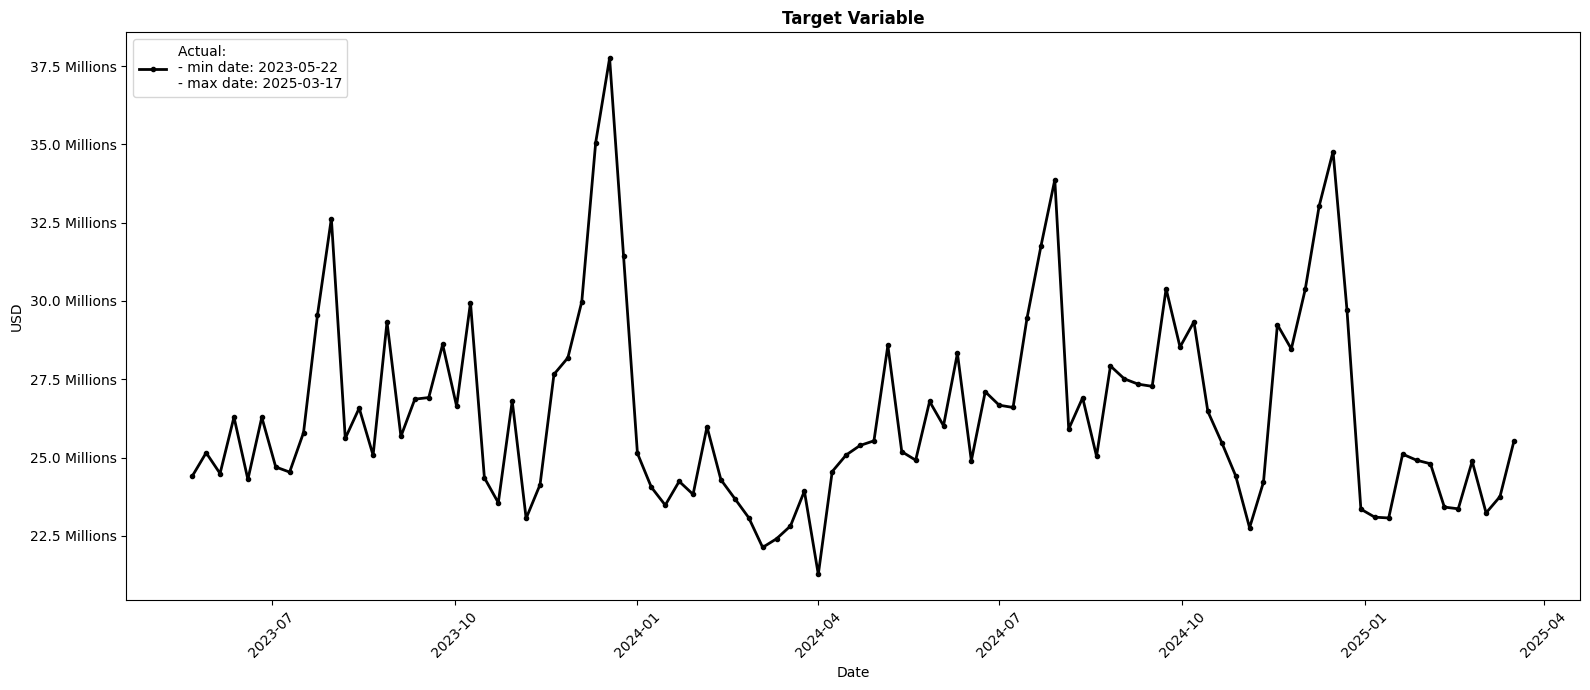

In [194]:
df_to_plot = (
    pd.pivot_table(
        df.drop_duplicates(),
        index=[date_var],
        values=[y],
        aggfunc="sum",
        fill_value=np.nan
    )
    .reset_index()
)

max_date = df_to_plot[date_var].max()

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(
    df_to_plot[date_var],
    df_to_plot[y],
    color="black",
    linewidth=2,
    marker="o",
    markersize=3,
    label=f"Actual: \n- min date: {df_to_plot[date_var].min():%Y-%m-%d} \n- max date: {max_date:%Y-%m-%d}",
    zorder=5
)

ax.set_title("Target Variable", fontsize=12, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("USD")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:.1f} Millions"))
plt.xticks(rotation=45)
plt.tight_layout()

Cluster 1 - 
Min date: 2023-05-22 00:00:00 
Max date: 2025-03-17 00:00:00
Cluster 0 - 
Min date: 2023-05-22 00:00:00 
Max date: 2025-03-17 00:00:00


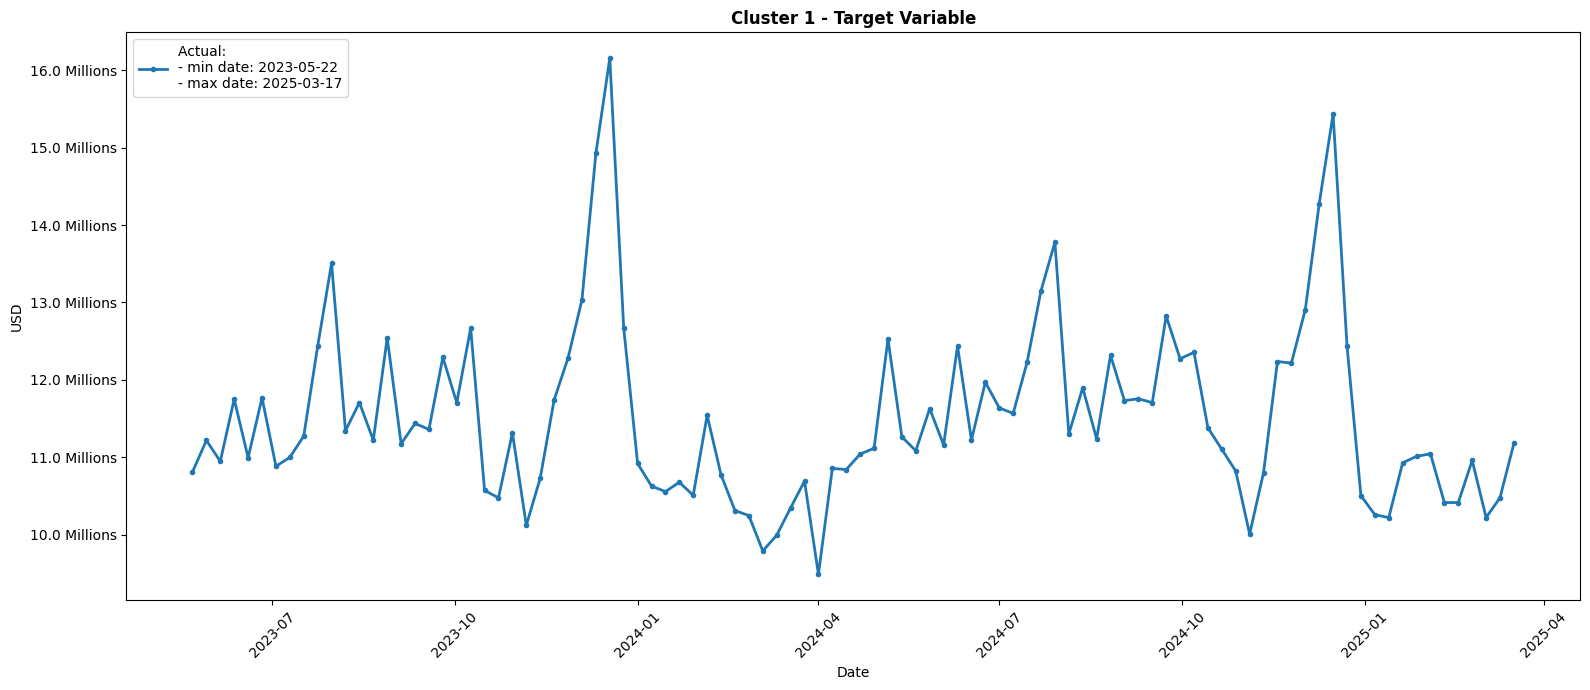

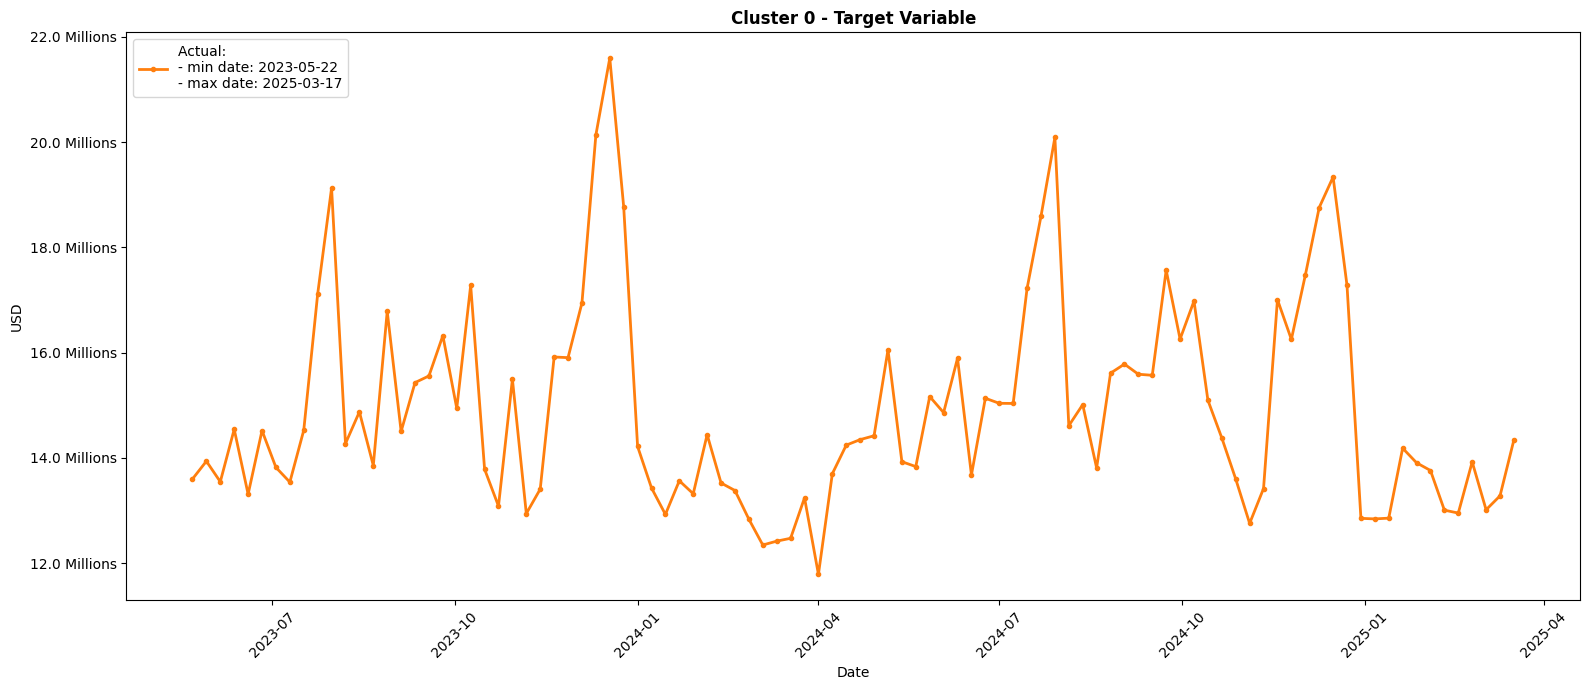

In [195]:
dict_colors = {c: color for c, color in zip(df['profile_cluster'].unique(), sns.color_palette("tab10", n_colors=df['profile_cluster'].nunique()))}
for c in df['profile_cluster'].unique():
        df_to_plot = (
        pd.pivot_table(
                df.loc[df['profile_cluster']==c].drop_duplicates(),
                index=[date_var],
                values=[y],
                aggfunc="sum",
                fill_value=np.nan
        )
        .reset_index()
        )

        max_date = df_to_plot[date_var].max()

        fig, ax = plt.subplots(figsize=(16, 7))
        ax.plot(
        df_to_plot[date_var],
        df_to_plot[y],
        color=dict_colors[c],
        linewidth=2,
        marker="o",
        markersize=3,
        label=f"Actual: \n- min date: {df_to_plot[date_var].min():%Y-%m-%d} \n- max date: {max_date:%Y-%m-%d}",
        zorder=5
        )

        ax.set_title(f"Cluster {c} - Target Variable", fontsize=12, fontweight="bold")
        ax.set_xlabel("Date")
        ax.set_ylabel("USD")
        ax.legend(loc="upper left")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:.1f} Millions"))
        plt.xticks(rotation=45)
        plt.tight_layout()
        print(f"Cluster {c} - \nMin date:", min(df_to_plot[date_var]), "\nMax date:", max(df_to_plot[date_var]))

## Set training start and end date

In [200]:
training_start_date=pd.to_datetime(training_start_date )
training_end_date=pd.to_datetime(training_end_date )

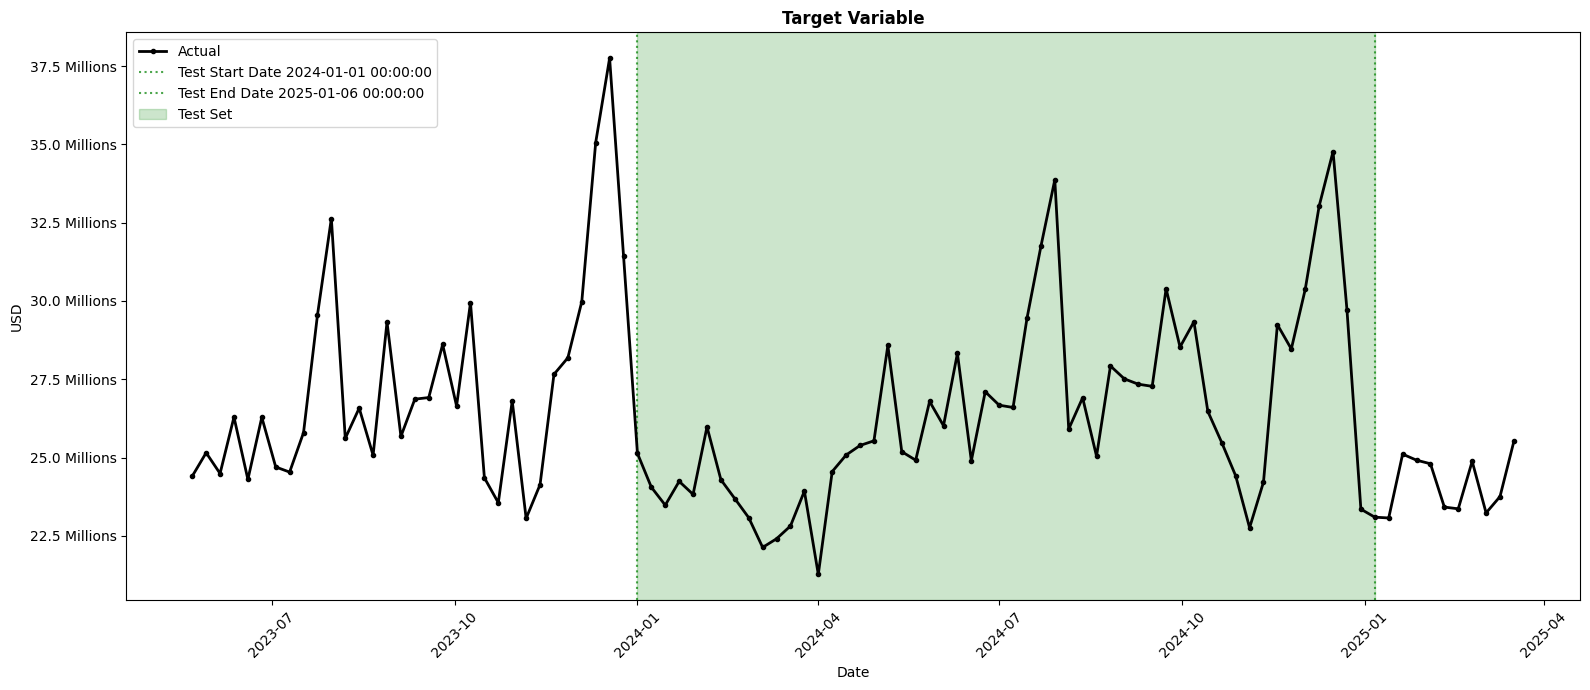

In [197]:
df_to_plot = pd.pivot_table(df.drop_duplicates(), index=[date_var], values=[y], aggfunc='sum', fill_value=np.nan).reset_index()

# Aggregate y
fig, ax = plt.subplots(figsize=(16, 7))

# Historical actuals
ax.plot(df_to_plot[date_var], df_to_plot[y],
        color='black', linewidth=2, marker='o', markersize=3,
        label='Actual', zorder=5)
ax.axvline(x=training_start_date, color='green', linestyle=':', alpha=0.7, label=f'Test Start Date {training_start_date}')
ax.axvline(x=training_end_date, color='green', linestyle=':', alpha=0.7, label=f'Test End Date {training_end_date}')
ax.axvspan(training_start_date, training_end_date, color = 'green', alpha = 0.2, label = 'Test Set')
ax.set_title(f'Target Variable', fontsize=12, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('USD')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f} Millions'))
plt.xticks(rotation=45); plt.tight_layout()

# ✅ CHECK POINT with the data scientist: set forecasting period

Plot up the target as the sum across all time series available, identify with a green are the prediction start date and the prediction end date,  Do the same across all profile_cluster available.

Then ask for the out-of-sample window and add it as an additional windows to the plots 
Make sure that oos period MUST be after training period, this is to avoid data leakage

In [201]:
forecast_start_date=pd.to_datetime(forecast_start_date)
forecast_end_date=pd.to_datetime(forecast_end_date)

# Checks
if forecast_start_date>=forecast_end_date:
    raise ValueError("OOS start date must be before OOS end date.")
if forecast_start_date<=training_start_date:
    raise ValueError("OOS start date must be after training start date.")
if forecast_start_date<=training_end_date:
    raise ValueError("OOS start date must be after training end date.")


# Functions

## Utils

In [105]:
class Utils:
    def get_static_cols(df, id_col, exclude_cols=None):
        """
        Returns columns that are constant within each unique_id (static covariates).
        """
        if exclude_cols is None:
            exclude_cols = []
        
        candidate_cols = [c for c in df.columns if c not in [id_col, 'ds'] + exclude_cols]
        
        static = []
        non_static = []
        for col in candidate_cols:
            n_unique_per_id = df.groupby(id_col)[col].nunique()
            if (n_unique_per_id <= 1).all():
                static.append(col)
            else:
                non_static.append(col)
        
        return static, non_static
    
    def get_binary_cols(df, exclude_cols=None):
        """
        Returns columns that contain only binary values (0 and 1).
        
        Parameters
        ----------
        df : pd.DataFrame
        exclude_cols : list, optional
            Columns to exclude from the search
        
        Returns
        -------
        list of binary column names
        """
        if exclude_cols is None:
            exclude_cols = []
        
        binary_cols = []
        for col in df.columns:
            if col in exclude_cols:
                continue
            unique_vals = set(df[col].dropna().unique())
            if unique_vals.issubset({0, 1}):
                binary_cols.append(col)
        
        return binary_cols
    
    def find_date(df: pd.DataFrame) -> str:
        """
        Finds date columns in a dataframe
        :params: df as dataframe
        :return: a string
        """
        dates = list(df.select_dtypes(include=['datetime','datetime64[ns, UTC]']).drop_duplicates().columns)
            
        if len(dates)==1:
            print('find_date, date_col found:', dates)
            date_col = dates[0]
        elif len(dates)==0:
            dates = list(df.select_dtypes(include=['period[M]']).drop_duplicates().columns)
            print('find_date, date_col found:', dates)
            date_col = dates[0]
        else:
            date_col = dates.copy()
        
        if (len(date_col)==0):
            raise Exception('find_date, no date_col found')      
            
            
        return str(object=date_col)
    
    def get_proper_data_types(df, unique_id, y):
        """
        1) Extract date features for MLForecast
        2) Identify static vs non-static features for MLForecast
        3) Identify numeric columns and convert to numeric
        4) Identify binary columns (subset of numeric with only 0/1 values)
        5) Identify categorical columns (excluding the series id)
        """
        # Date features extraction for MLForecast (will be used in the model fitting and prediction)
        date_var = Utils.find_date(df)  # prints detected date features and frequency, but we will create our own customized features below
        
        if date_var=='ds':
            df['ds'] = pd.to_datetime(df['ds'])
        else:
            df[date_var] = pd.to_datetime(df[date_var])
            df = df.rename(columns={date_var: 'ds'})
            
        df['year'] = df['ds'].dt.year
        df['month'] = df['ds'].dt.month
        df['week'] = df['ds'].dt.isocalendar().week
        date_features = ["year", "month", "week"]

        # Identify static vs non-static features for MLForecast
        static_cols, non_static_cols = Utils.get_static_cols(df, unique_id, exclude_cols=[y] + date_features)

        print(f"✅ Static columns ({len(static_cols)}):")
        for c in static_cols:
            df[c] = df[c].astype("category")

            print(f"  - {c}")

        print(f"\n⚠️ Non-static columns ({len(non_static_cols)}) - excluded from static covariates:")
        for c in non_static_cols:
            print(f"  - {c}")

        # Identify numeric columns
        numeric_cols = df.select_dtypes(include=['float64', 'float32', "int64"]).columns.tolist()
        for c in numeric_cols:
            print(f"Numeric (float) column: \n {c}")

        # Define numeric variables and convert to numeric, coercing errors to NaN
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")
                
        # Identify binary columns (subset of numeric with only 0/1 values)
        binary_cols = Utils.get_binary_cols(df, exclude_cols=[unique_id, 'ds', y])
        print(f"✅ Found {len(binary_cols)} binary columns:")
        for c in binary_cols:
            print(f"  - {c}")
            
        # Identify categorical columns (excluding the series id)
        categorical_cols = [
            c for c in df.select_dtypes(include=["object", "category", "bool", "int64"]).columns
            if (c != unique_id) & (c in binary_cols) & (c not in date_features) & (c not in static_cols)
        ]

        for col in categorical_cols:
            df[col] = df[col].astype("category")

        print(f"✅ Found {len(categorical_cols)} categorical columns:")
        for c in categorical_cols:
            print(f"- {c} | dtype={df[c].dtype} | unique={df[c].nunique()}")
            
        return date_features, static_cols, non_static_cols, numeric_cols, binary_cols, categorical_cols

## CalendarFeatures class

In [106]:
class CalendarFeatures:
    def __init__(self, config, df: pd.DataFrame) -> None:
        self.config = config
        self.df: pd.DataFrame = df
        self.date_var: str = Utils.find_date(df=self.df)    
        self.country: str = self.config.features.holiday_country
    
    def add_holidays_by_country(self)-> pd.DataFrame:
        """
        Adds holidays a dummy variable (0/1) to dataframe
        :params: dataframe, date_var as string, country as string
        :return: a Pandas dataframe
        """
        return CalendarFeatures.add_holidays_by_country_static(self.df.copy(), self.date_var, self.country)
   
    def add_weekdays(self)-> pd.DataFrame:
        """
        Adds weekdays a dummy variables (0/1) for each weekday to dataframe
        :params: dataframe, date_var as string
        :return: a Pandas dataframe
        """
        return CalendarFeatures.add_weekdays_static(self.df.copy(), self.date_var)
    
    def add_months(self)-> pd.DataFrame:
        """
        Adds months a dummy variables (0/1) for each month to dataframe
        :params: dataframe, date_var as string
        :return: a Pandas dataframe
        """
        
        df: pd.DataFrame = self.df.copy()
        date_var = self.date_var
        for i in range(1, 13):
            if i < 10:
                varname = 'month_0' + str(i)
            else:
                varname = 'month_' + str(i)
            
            df.loc[:, varname] = df.loc[:, date_var].apply(lambda x: int(1) if x.month == i else int(0))
        return df 

    def merge_holidays_by_date(self, df_holidays, id)-> pd.DataFrame:
        """
        Merge Holiday df with the train df
        :params: df as dataframe, df_holidays as df containing info on holidays, id as string
        :return: a pandas dataframe
        """
        df: pd.DataFrame = self.df.copy()
        date_var = Utils.find_date(df=df)
        date_var_holidays = Utils.find_date(df=df_holidays)
        
        cols_to_keep = list(df.columns)
        
        df['date_key'] = df[date_var].dt.year.astype(str) + df[date_var].dt.month.astype(str) + df[date_var].dt.day.astype(str)
        df_holidays['date_key'] = df_holidays[date_var_holidays].dt.year.astype(str) + df_holidays[date_var_holidays].dt.month.astype(str) + df_holidays[date_var_holidays].dt.day.astype(str)
        
        df.loc[:, 'holidays'] = int(0)
        df_merge = pd.merge(df, df_holidays, how="left", on=["date_key", id], indicator=True)
        df_merge.loc[df_merge._merge=='both', 'holidays'] = int(1)
        
        cols_to_keep = cols_to_keep + ['holidays']
        df = df_merge[cols_to_keep].copy()

        return df
    
    def merge_additional_days_off(self, df_metadata, id, dict_days_off)-> pd.DataFrame:
        """
        Merge Site Weekend data with train df
        :params: df as dataframe, df_metadata as df containing additional info, id as string, dict_days_off as dictionary 
        :return: a pandas dataframe
        """
        df: pd.DataFrame = self.df.copy()
        date_var = Utils.find_date(df=df)

        # Only weekly leaves on Friday, Saturday and Sunday
        list_days_off = list(dict_days_off.keys())
        df.loc[:, 'day_off'] = int(0)
        for d in list_days_off: 
            leave = (df[date_var].dt.dayofweek == dict_days_off[d]) & (df[id].isin(df_metadata[df_metadata[d]][id]))
            df.loc[leave==True, 'day_off'] = int(1)

        df['day_off'] = df['day_off'].astype(dtype="int8")

        return df

    @staticmethod
    def add_holidays_by_country_static(df, date_var, country):
        """
        Adds holidays a dummy variable (0/1) to dataframe (static version).
        :params: df as dataframe, date_var as string, country as string
        :return: a Pandas dataframe
        """
        if 'holidays' in list(df.columns):
            print('add_holidays_by_country: holidays column already present')
        else:
            holiday_cal = eval("holidays." + country + "()")
            date_holidays = df.loc[:, date_var].apply(lambda x: int(1) if x in holiday_cal else int(0))
            date_holidays = pd.DataFrame(date_holidays)
            date_holidays.columns = pd.Index(['holidays'])
            df = pd.concat([df, date_holidays], axis=1)
        return df

    @staticmethod
    def add_weekdays_static(df, date_var):
        """
        Adds weekdays dummy variables (0/1) for each weekday to dataframe (static version).
        :params: df as dataframe, date_var as string
        :return: a Pandas dataframe
        """
        df.loc[:,'wd_mon'] = df.loc[:, date_var].apply(lambda x: int(1) if x.weekday() == 0 else int(0))
        df.loc[:,'wd_tue'] = df.loc[:, date_var].apply(lambda x: int(1) if x.weekday() == 1 else int(0))
        df.loc[:,'wd_wed'] = df.loc[:, date_var].apply(lambda x: int(1) if x.weekday() == 2 else int(0))
        df.loc[:,'wd_thu'] = df.loc[:, date_var].apply(lambda x: int(1) if x.weekday() == 3 else int(0))
        df.loc[:,'wd_fri'] = df.loc[:, date_var].apply(lambda x: int(1) if x.weekday() == 4 else int(0))
        df.loc[:,'wd_sat'] = df.loc[:, date_var].apply(lambda x: int(1) if x.weekday() == 5 else int(0))
        df.loc[:,'wd_sun'] = df.loc[:, date_var].apply(lambda x: int(1) if x.weekday() == 6 else int(0))
        return df

## SimilarDay class

In [107]:
class SimilarDayFeatures:
    def __init__(self, config, df: pd.DataFrame) -> None:
        self.config = config
        self.df: pd.DataFrame = df
        self.date_var: str = Utils.find_date(df=self.df)
        self.country: str = config.features.holiday_country 
        self.dates: pd.Series = df[self.date_var]
        
    def get_similar_days_in_previous_year(self) -> pd.Series:
        """
        Retrieves the similar day for a given date. 
        :param dates: a list-like object of dates, country as string
        :return: a Pandas series of similar days
        """
        country: str = self.country
        dates: pd.Series = self.dates
        d = pd.to_datetime(pd.Series(dates))        
        holidays = eval("h." + country.capitalize() + "()")
        return d.apply(lambda x: SimilarDayFeatures._get_similar_day_in_previous_year(x, holidays))

    def get_similar_days_in_previous_week(self) -> pd.Series:
        """
        Retrieves the similar day for a given date.
        :param dates: a list-like object of dates, country as string
        :return: a Pandas series of similar days
        """
        country: str = self.country
        dates: pd.Series = self.dates
        d = pd.to_datetime(pd.Series(dates))
        holidays = eval("h." + country.capitalize() + "()")
        return d.apply(lambda x: SimilarDayFeatures._get_similar_day_in_previous_week(x, holidays))


    def _get_similar_day_in_previous_year(d, holiday_calendar):
        """
        Retrieves the similar day for a given date. If the given date is not an holiday, the similar day is the
        closest day of the previous year in terms of calendar position which shares the weekday. If such a date is an holiday,
        the same weekday of the week before is considered. 
        If the given date is an holiday, its similar day is the closest holiday to the given date in the previous year.
        :param d: a date
        :param holiday_calendar: a calendar from holidays package
        :return: the similar day
        """
        if not d or pd.isna(d):
            return None

        new_date = d - relativedelta(years=1)
        holiday = holiday_calendar.get(d)
        diff = d.weekday() - new_date.weekday() if d.weekday() >= new_date.weekday() \
            else d.weekday() - new_date.weekday() + 7

        if not holiday:
            new_date = new_date + datetime.timedelta(days=diff)
            while holiday_calendar.get(new_date):
                new_date = new_date - datetime.timedelta(days=7)

        return new_date

    def _get_similar_day_in_previous_week(d, holiday_calendar):
        """
        Retrieves the similar day for a given date. If the given date is not an holiday, the similar day is the
        closest day of the previous year in terms of calendar position which shares the weekday. If such a date is an holiday,
        the same weekday of the week before is considered. 
        If the given date is an holiday, its similar day is the closest holiday to the given date in the previous year.
        :param d: a date
        :param holiday_calendar: a calendar from holidays package
        :return: the similar day
        """
        if not d or pd.isna(d):
            return None

        new_date = d - relativedelta(weeks=1)
        holiday = holiday_calendar.get(d)
        diff = d.weekday() - new_date.weekday() if d.weekday() >= new_date.weekday() \
            else d.weekday() - new_date.weekday() + 7

        if not holiday:
            new_date = new_date + datetime.timedelta(days=diff)
            while holiday_calendar.get(new_date):
                new_date = new_date - datetime.timedelta(days=7)

        return new_date
    

class SimilarDay: 

    def get_similar_days_in_previous_year(dates, country):
        """
        Retrieves the similar day for a given date. 
        :param dates: a list-like object of dates, country as string
        :return: a Pandas series of similar days
        """
        d = pd.to_datetime(pd.Series(dates))        
        holidays = eval("h." + country.capitalize() + "()")
        return d.apply(lambda x: SimilarDay.get_similar_day_in_previous_year(x, holidays))

    def get_similar_days_in_previous_week(dates, country):
        """
        Retrieves the similar day for a given date.
        :param dates: a list-like object of dates, country as string
        :return: a Pandas series of similar days
        """
        d = pd.to_datetime(pd.Series(dates))
        holidays = eval("h." + country.capitalize() + "()")
        return d.apply(lambda x: SimilarDay.get_similar_day_in_previous_week(x, holidays))


    def get_similar_day_in_previous_year(d, holiday_calendar):
        """
        Retrieves the similar day for a given date. If the given date is not an holiday, the similar day is the
        closest day of the previous year in terms of calendar position which shares the weekday. If such a date is an holiday,
        the same weekday of the week before is considered. 
        If the given date is an holiday, its similar day is the closest holiday to the given date in the previous year.
        :param d: a date
        :param holiday_calendar: a calendar from holidays package
        :return: the similar day
        """
        if not d or pd.isna(d):
            return None

        new_date = d - relativedelta(years=1)
        holiday = holiday_calendar.get(d)
        diff = d.weekday() - new_date.weekday() if d.weekday() >= new_date.weekday() \
            else d.weekday() - new_date.weekday() + 7

        if not holiday:
            new_date = new_date + datetime.timedelta(days=diff)
            while holiday_calendar.get(new_date):
                new_date = new_date - datetime.timedelta(days=7)

        return new_date

    def get_similar_day_in_previous_week(d, holiday_calendar):
        """
        Retrieves the similar day for a given date. If the given date is not an holiday, the similar day is the
        closest day of the previous year in terms of calendar position which shares the weekday. If such a date is an holiday,
        the same weekday of the week before is considered. 
        If the given date is an holiday, its similar day is the closest holiday to the given date in the previous year.
        :param d: a date
        :param holiday_calendar: a calendar from holidays package
        :return: the similar day
        """
        if not d or pd.isna(d):
            return None

        new_date = d - relativedelta(weeks=1)
        holiday = holiday_calendar.get(d)
        diff = d.weekday() - new_date.weekday() if d.weekday() >= new_date.weekday() \
            else d.weekday() - new_date.weekday() + 7

        if not holiday:
            new_date = new_date + datetime.timedelta(days=diff)
            while holiday_calendar.get(new_date):
                new_date = new_date - datetime.timedelta(days=7)
        # elif holiday == 'Pasqua di Resurrezione':
        #     new_date = dateutil.easter.easter(new_date.year)
        # elif holiday == "LunedÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ dell'Angelo":
        #     new_date = dateutil.easter.easter(new_date.year) + datetime.timedelta(days=1)

        return new_date
    
    def fill_exog_similar_week(X_df, df, exog_cols, ds_col, id_col):
        """Fill missing exogenous values in X_df using same-ISO-week data from the prior year.
        
        For each (store, future_date) row with NaN exogenous values, looks up the
        historical row from the same store and closest matching ISO week in the
        previous year. Falls back gracefully if no match is found (leaves NaN for
        downstream last-known-value filling).
        """
        if X_df[exog_cols].isna().sum().sum() == 0:
            print("No missing exogenous values — similar-week fill not needed.")
            return X_df

        X_df = X_df.copy()

        # Precompute ISO week for historical data
        hist = df[[id_col, ds_col] + exog_cols].copy()
        hist[ds_col] = pd.to_datetime(hist[ds_col])
        hist['_iso_week'] = hist[ds_col].dt.isocalendar().week.astype(int)
        hist['_year'] = hist[ds_col].dt.year

        # ISO week for future dates
        X_df['_iso_week'] = pd.to_datetime(X_df[ds_col]).dt.isocalendar().week.astype(int)
        X_df['_target_year'] = pd.to_datetime(X_df[ds_col]).dt.year

        filled_count = 0
        for idx, row in X_df.iterrows():
            if not row[exog_cols].isna().any():
                continue

            store = row[id_col]
            iso_wk = row['_iso_week']
            target_yr = row['_target_year']

            # Look for same store, same ISO week, prior years (most recent first)
            candidates = hist[
                (hist[id_col] == store) & (hist['_iso_week'] == iso_wk) & (hist['_year'] < target_yr)
            ].sort_values('_year', ascending=False)

            if candidates.empty:
                continue

            best_match = candidates.iloc[0]
            for col in exog_cols:
                if pd.isna(row[col]):
                    X_df.at[idx, col] = best_match[col]
            filled_count += 1

        X_df = X_df.drop(columns=['_iso_week', '_target_year'])
        remaining_nans = X_df[exog_cols].isna().sum().sum()
        print(f"Similar-week fill: {filled_count} rows filled, {remaining_nans} NaN values remaining.")
        return X_df



## StandardDemand class

In [108]:
class StandardDemand:   
    def get_standard_demand_as_mean(df, id, date_var, var, country):
        """
        Retrieves the standard consumption for a given date as hourly monthly mean differentiated by holiday, weekend, weekdays. 
        :params: dataframe and date_var as string, var as string, country as string
        :return: the similar day
        """

        df = CalendarFeatures.add_holidays_by_country_static(df, date_var, country)
        df = CalendarFeatures.add_weekdays_static(df, date_var)
        df.loc[:, 'day'] = df.loc[:, date_var].dt.day
        df.loc[:, 'hour'] = df.loc[:, date_var].dt.hour
        df.loc[:, 'month'] = df.loc[:, date_var].dt.month
        
        timedelta = Utils.delta_format(abs(np.diff(df[date_var])).mean())
        freq = Utils.find_freq(timedelta)
        
        if freq == 'D':
            freq_var='day'
        else:
            freq_var='hour'
        
        # Compute standard consumption as means        
        mask = (~df[var].isnull()) &  ((df.wd_mon==1) | (df.wd_tue==1) | (df.wd_wed==1) | (df.wd_thu==1) | (df.wd_fri==1)) & (df.holidays==0) 
        df_mean_weekdays = pd.pivot_table(df.loc[mask==True, ], index=[id, 'month', freq_var], values=var, aggfunc=np.mean).reset_index()
        new_var = var + '_std_weekdays'
        df_mean_weekdays.rename(columns={var: new_var}, inplace=True)
        df_mean_weekdays.loc[df_mean_weekdays[new_var]<0, new_var] = 0
        
        mask = (~df[var].isnull()) & ((df.wd_sat==1) | (df.wd_sun==1)) & (df.holidays==0) 
        df_mean_weekend = pd.pivot_table(df.loc[mask==True, ], index=[id, 'month', freq_var], values=var, aggfunc=np.mean).reset_index()
        new_var = var + '_std_weekend'
        df_mean_weekend.rename(columns={var: new_var}, inplace=True)
        df_mean_weekend.loc[df_mean_weekend[new_var]<0, new_var] = 0
        
        mask = (~df[var].isnull()) & (df.holidays==1) 
        df_mean_holidays = pd.pivot_table(df.loc[mask==True, ], index=[id, 'month', freq_var], values=var, aggfunc=np.mean).reset_index()
        new_var = var + '_std_holidays'
        df_mean_holidays.rename(columns={var: new_var}, inplace=True)
        df_mean_holidays.loc[df_mean_holidays[new_var]<0, new_var] = 0
        
        # Merging
        dfs = [df_mean_holidays, df_mean_weekdays, df_mean_weekend]
        df_mean = reduce(lambda left,right: pd.merge(left,right,how='outer', on=[id, 'month', freq_var], validate='1:1'), dfs)
        df = pd.merge(df, df_mean, how='left', on=[id, 'month', freq_var], validate='m:1')
        
        return df
    
    
    def get_minimum_demand(df, date_var, var, country):
        """
        Retrieves the minimum consumption for a given date as hourly monthly minimum value differentiated by holiday, weekend, night. 
        :params: dataframe and date_var as string, var as string, country as string
        :return: the similar day
        """

        df = CalendarFeatures.add_holidays_by_country_static(df, date_var, country)
        df = CalendarFeatures.add_weekdays_static(df, date_var)
        df.loc[:, 'day'] = df.loc[:, date_var].dt.day
        df.loc[:, 'hour'] = df.loc[:, date_var].dt.hour
        df.loc[:, 'month'] = df.loc[:, date_var].dt.month
        
        timedelta = Utils.delta_format(abs(np.diff(df[date_var])).mean())
        freq = Utils.find_freq(timedelta)
        
        if freq == 'D':
            freq_var='day'
        else:
            freq_var='hour'
        
        # Compute min consumption        
        mask = (~df[var].isnull()) & (df.holidays==0) & ((df.wd_mon==1) | (df.wd_tue==1) | (df.wd_wed==1) | (df.wd_thu==1) | (df.wd_fri==1))
        df_min_weekdays = pd.pivot_table(df.loc[mask==True, ], index=[id, 'month', freq_var], values=var, aggfunc=np.min).reset_index()
        new_var = var + '_min_weekdays'
        df_min_weekdays.rename(columns={var: new_var}, inplace=True)
        df_min_weekdays.loc[df_min_weekdays[new_var]<0, new_var] = 0
        
        mask = (~df[var].isnull()) & ((df.wd_sat==1) | (df.wd_sun==1)) & (df.holidays==0) 
        df_min_weekend = pd.pivot_table(df.loc[mask==True, ], index=[id, 'month', freq_var], values=var, aggfunc=np.min).reset_index()
        new_var = var + '_min_weekend'
        df_min_weekend.rename(columns={var: new_var}, inplace=True)
        df_min_weekend.loc[df_min_weekend[new_var]<0, new_var] = 0
        
        mask = (~df[var].isnull()) & (df.holidays==1) 
        df_min_holidays = pd.pivot_table(df.loc[mask==True, ], index=[id, 'month', freq_var], values=var, aggfunc=np.min).reset_index()
        new_var = var + '_min_holidays'
        df_min_holidays.rename(columns={var: new_var}, inplace=True)
        df_min_holidays.loc[df_min_holidays[new_var]<0, new_var] = 0
        
        # Merging
        dfs = [df_min_holidays, df_min_weekdays, df_min_weekend]
        df_min = reduce(lambda left,right: pd.merge(left,right,how='outer', on=[id, 'month', freq_var], validate='1:1'), dfs)
        df = pd.merge(df, df_min, how='left', on=[id, 'month', freq_var], validate='m:1')
        
        return df
    
    def fill_exog_standard_consumption(X_df, df, exog_cols, ds_col, id_col):
        """Fill missing exogenous values using standard consumption (historical mean per store).
        
        For each store and each exogenous column, computes the mean across all
        historical periods and uses it to fill remaining NaN values.
        Intended as a middle tier between similar-week and last-known-value fills.
        """
        nan_before = X_df[exog_cols].isna().sum().sum()
        if nan_before == 0:
            print("No missing exogenous values — standard-consumption fill not needed.")
            return X_df

        X_df = X_df.copy()

        for col in exog_cols:
            if X_df[col].isna().sum() == 0:
                continue
            # Skip categorical columns — mean is only meaningful for numeric data
            if hasattr(df[col], 'cat') or df[col].dtype.name == 'category':
                continue
            # Historical mean per store
            mean_by_store = df.groupby(id_col)[col].mean()
            fill_values = X_df[id_col].map(mean_by_store)
            # Convert column to float64 to safely accept float fill values (handles nullable int like UInt32)
            X_df[col] = X_df[col].astype('float64').fillna(fill_values)

        nan_after = X_df[exog_cols].isna().sum().sum()
        print(f"Standard-consumption fill: {nan_before - nan_after} NaN values filled, {nan_after} remaining.")
        return X_df


## LastKnownValue class

In [109]:
class LastKnownValue:
    def fill_exog_last_known(X_df, df, exog_cols, ds_col, id_col):
        """Fill missing exogenous values using the last known value per store.
        
        For each store and each exogenous column, takes the most recent
        historical value and uses it to fill remaining NaN values.
        Intended as the final fallback after similar-week and standard-consumption fills.
        """
        nan_before = X_df[exog_cols].isna().sum().sum()
        if nan_before == 0:
            print("No missing exogenous values — last-known-value fill not needed.")
            return X_df

        X_df = X_df.copy()

        for col in exog_cols:
            if X_df[col].isna().sum() == 0:
                continue
            last_exog = (
                df.sort_values(ds_col)
                .groupby(id_col)[col]
                .last()
            )
            X_df[col] = X_df[col].fillna(X_df[id_col].map(last_exog))

        nan_after = X_df[exog_cols].isna().sum().sum()
        print(f"Last-known-value fill: {nan_before - nan_after} NaN values filled, {nan_after} remaining.")
        return X_df

## rolling_train_and_predict_with_transform_oos

In [110]:
def get_future_exog_df(df, pred_ts, feature_cols, static_features, ds_col, id_col):
    cols_to_keep = [f for f in feature_cols if f not in static_features and f in df.columns]
    future_exog_df = df.loc[df[ds_col] >= pred_ts, [ds_col, id_col] + cols_to_keep].copy()
    if not future_exog_df.empty:
        print(f"Future_exog_df for {pred_ts}: {future_exog_df.shape[0]} rows, from {future_exog_df[ds_col].min().date()} to {future_exog_df[ds_col].max().date()}" )
    else:
        print(f"Future_exog_df for {pred_ts}: empty (fully out-of-sample)")
    return future_exog_df

def build_X_df(mlf, df, future_exog_df, feature_cols, static_features, pred_ts, n, ds_col, id_col):   
    cols_to_keep = [f for f in feature_cols if f not in static_features and f in df.columns]
    
    X_df = mlf.make_future_dataframe(n)
    X_df = X_df.merge(
        future_exog_df,
        on=[id_col, ds_col],
        how="left"
    )

    print(f"X_df for {pred_ts}: {X_df.shape[0]} rows, from {X_df[ds_col].min().date()} to {X_df[ds_col].max().date()}" )
    
    # 1) Similar-week fill: use same ISO week from the prior year
    X_df = SimilarDay.fill_exog_similar_week(X_df, df, cols_to_keep, ds_col, id_col)
    
    # 2) Standard consumption fill: historical mean per store
    X_df = StandardDemand.fill_exog_standard_consumption(X_df, df, cols_to_keep, ds_col, id_col)
    
    # 3) Last-known-value fallback: most recent value per store
    X_df = LastKnownValue.fill_exog_last_known(X_df, df, cols_to_keep, ds_col, id_col)
    
    missing = mlf.get_missing_future(n, X_df)
    if len(missing) > 0:
        print("Warning: There are still missing values in X_df after filling. Check get_missing_future output for details.")
    else:
        print("No missing values in X_df after filling.")    
    
    return X_df

In [240]:
def rolling_train_and_predict_with_transform_oos(
    df,
    static_features,
    feature_cols,
    eval_dates,
    training_end_date,
    forecast_end_date,
    mlf_date_features=["month", "year"],
    lags=[1, 2],
    freq="MS",
    id_col="unique_id",
    ds_col="ds",
    y_col="y",
):
    df = df.copy()
    df[ds_col] = pd.to_datetime(df[ds_col])
    
    
    print("Evaluation dates:", eval_dates)
    print("Max train date:", training_end_date)
    print("Forecast end date:", forecast_end_date)
    
    transform_configs = {
        "identity": [],
        "std": [LocalStandardScaler()],
        "diff1": [Differences([1])],
    }
    
    all_forecasts = None
    
    for name, tfs in transform_configs.items():
        with mlflow.start_run(
                    run_name=f"transform_{name}",
                    nested=True,
                    tags={"transform": name,},
                ) as parent_run:
            print('Model', name)
            print(f"Transform config '{name}': {[type(tf).__name__ for tf in tfs]}")
            rolling_forecasts = None
            for date in eval_dates:
                print(f"\nProcessing evaluation date: {date}")
                pred_ts = pd.to_datetime(date)
                
                if (pred_ts <= training_end_date):
                    in_sample = True
                    n = 1
                    print(pred_ts, 'is in-sample, rolling forecast')
                else:
                    in_sample = False
                    future_dates = pd.date_range(start=pred_ts, end=pd.to_datetime(forecast_end_date), freq=freq)
                    n = len(future_dates)
                    print(f'{pred_ts}, is out-of-sample. {n} periods ahead to {forecast_end_date}')
                    
                with mlflow.start_run(
                    run_name=f"transform_{name}_date_{date}",
                    nested=True,
                    tags={"transform": name, "date": str(date), "in_sample": str(in_sample)},
                    ) as child_run:
                
                    # 1. Training
                    train_df = df[df[ds_col] < pred_ts].copy()
                    print(f"Training data for {pred_ts}: {train_df.shape[0]} rows, from {train_df[ds_col].min().date()} to {train_df[ds_col].max().date()}" )
                    if train_df.empty:
                        raise ValueError("No training data before prediction_date.")

                    base_model = LGBMRegressor(random_state=42)

                    mlf = MLForecast(
                        models=[base_model],
                        freq=freq,
                        lags=lags,
                        date_features=mlf_date_features,
                        target_transforms=tfs,
                    )

                    mlf.fit(
                        train_df,
                        id_col=id_col,
                        time_col=ds_col,
                        target_col=y_col,
                        static_features=static_features,
                    )

                    # 2. Build exogenous future and predict
                    future_exog_df = get_future_exog_df(df, pred_ts, feature_cols, static_features, ds_col, id_col)
                    X_df = build_X_df(mlf, df, future_exog_df, feature_cols, static_features, pred_ts, n, ds_col, id_col)

                    # Drop date feature columns that mlforecast will generate internally
                    exog_cols = [c for c in feature_cols if c not in static_features and c not in mlf_date_features and c in df.columns]
                    if exog_cols:
                        # Drop static_cols and date_features columns (month, year) to avoid duplication;
                        # mlforecast generates date_features internally during prediction.
                        print(f"Exogenous time-varying columns are present. Dropping static and date feature columns from X_df before prediction: {static_features + mlf_date_features}")
                        cols_to_drop = [c for c in static_features + mlf_date_features if c in X_df.columns]
                        fcst = mlf.predict(n, X_df=X_df.drop(columns=cols_to_drop))
                        fcst.rename(columns={"LGBMRegressor": "y_hat_" + name}, inplace=True)
                    else:
                        print(f"Exogenous time-varying columns are not present. Forecasting with no exogenous features.")
                        fcst = mlf.predict(n)
                        fcst.rename(columns={"LGBMRegressor": "y_hat_" + name}, inplace=True)
                    
                    cols_to_drop = [c for c in mlf_date_features if c in X_df.columns] + [c for c in static_features if c in X_df.columns]
                    if cols_to_drop:
                        X_df = X_df.drop(columns=cols_to_drop)

                    # Accumulate forecasts by concatenating rows (not merging columns)
                    if rolling_forecasts is None:
                        rolling_forecasts = fcst.copy()
                    else:
                        rolling_forecasts = pd.concat([rolling_forecasts, fcst], ignore_index=True)
                        
                    mlflow.log_param("date", pred_ts)
                    mlflow.log_param("transform", name)
                    mlflow.log_param("training_end_date", training_end_date)
                    mlflow.log_param("in_sample", in_sample)

            # Drop duplicate (id, ds) rows from overlapping OOS predictions, keep first
            rolling_forecasts = rolling_forecasts.drop_duplicates(subset=[id_col, ds_col], keep="first")

            # After all dates for this transform: rename prediction column
            pred_cols = [c for c in rolling_forecasts.columns if c not in (id_col, ds_col)]
            new_col_name = f"y_hat_{name}"
            
            if len(pred_cols) == 1:
                rolling_forecasts = rolling_forecasts.rename(columns={pred_cols[0]: new_col_name})
            else:
                raise ValueError(f"Unexpected forecast columns: {pred_cols}")
            
            ### Add metrics
            eval_results = df[[id_col, ds_col, y_col]].merge(rolling_forecasts, on=[id_col, ds_col], how='inner')

            if len(eval_results) > 0:
                y_true = eval_results[y_col]
                y_pred = eval_results[new_col_name] 

                rmse = np.sqrt(mean_squared_error(y_true, y_pred))
                print("RMSE", rmse)
                mlflow.log_metric(f'rmse_y_hat_{name}', rmse)

                mae = mean_absolute_error(y_true, y_pred)
                print("MAE", mae)
                mlflow.log_metric(f'mae_y_hat_{name}', mae)
            else:
                print("No actuals available for predictions, cannot compute metrics")
            
            mlflow.log_param("transform", name)
            mlflow.log_param("training_end_date", training_end_date)

            if all_forecasts is None:
                all_forecasts = rolling_forecasts[[id_col, ds_col, new_col_name]].copy()
            else:
                all_forecasts = all_forecasts.merge(
                    rolling_forecasts[[id_col, ds_col, new_col_name]],
                    on=[id_col, ds_col],
                    how="outer",
                )

    return all_forecasts

## rolling_train_and_predict_with_transforms

This function performs a rolling-origin evaluation across the test window defined by `training_start_date` and `training_end_date`.

In [112]:
def train_and_predict_with_transforms(
    df,
    static_features,
    prediction_date,
    date_features=["year", "month", "hour", "dayofweek"],  # CUSTOMIZED: hourly date features
    lags=[1, 24, 168],  # CUSTOMIZED: 1h, 1d, 1w lags
    freq="h",  # CUSTOMIZED: hourly frequency
    id_col="site_id",  # CUSTOMIZED: site_id
    ds_col="ds",
    y_col="value",  # CUSTOMIZED: value target
):
    df = df.copy()
    df[ds_col] = pd.to_datetime(df[ds_col])
    pred_ts = pd.to_datetime(prediction_date)
    
    train_df = df[df[ds_col] < pred_ts].copy()
    if train_df.empty:
        raise ValueError("No training data before prediction_date.")

    transform_configs = {
        "identity": [],
        "std": [LocalStandardScaler()],
        "diff1": [Differences([1])],
    }

    base_model = LGBMRegressor(random_state=42, verbose=-1)

    all_forecasts = None

    for name, tfs in transform_configs.items():
        mlf = MLForecast(
            models=[base_model],
            freq=freq,
            lags=lags,
            date_features=date_features,
            target_transforms=tfs,
        )

        mlf.fit(
            train_df,
            id_col=id_col,
            time_col=ds_col,
            target_col=y_col,
            static_features=static_features,
        )

        fcst = mlf.predict(1)

        pred_cols = [c for c in fcst.columns if c not in (id_col, ds_col)]
        if len(pred_cols) != 1:
            raise ValueError(f"Unexpected forecast columns: {fcst.columns}")

        pred_col = pred_cols[0]
        new_col_name = f"y_hat_{name}"
        fcst = fcst.rename(columns={pred_col: new_col_name})

        if all_forecasts is None:
            all_forecasts = fcst[[id_col, ds_col, new_col_name]].copy()
        else:
            all_forecasts = all_forecasts.merge(
                fcst[[id_col, ds_col, new_col_name]],
                on=[id_col, ds_col],
                how="inner",
            )

    return all_forecasts

In [113]:
def rolling_train_and_predict_with_transforms(
    df,
    static_features,
    training_start_date,
    training_end_date,
    date_features=["month", "year"],
    lags=[1, 2],
    freq="MS",
    id_col="unique_id",
    ds_col="ds",
    y_col="y",
):
    """
    Runs train_and_predict_with_transforms for each prediction date in
    [training_start_date, training_end_date] with given freq, and
    concatenates the results.
    """

    df = df.copy()
    df[ds_col] = pd.to_datetime(df[ds_col])

    start_ts = pd.to_datetime(training_start_date)
    end_ts = pd.to_datetime(training_end_date)

    prediction_dates = pd.date_range(start=start_ts, end=end_ts, freq=freq)

    all_results = []

    for pred_date in prediction_dates:
        try:
            fcst = train_and_predict_with_transforms(
                df=df,
                static_features=static_features,
                prediction_date=pred_date,
                date_features=date_features,
                lags=lags,
                freq=freq,
                id_col=id_col,
                ds_col=ds_col,
                y_col=y_col,
            )
            all_results.append(fcst)
        except ValueError as e:
            print(f"Skipping {pred_date.date()} -> {e}")

    if not all_results:
        raise ValueError("No predictions were generated for the given date range.")

    return pd.concat(all_results, ignore_index=True)

## compute_all_metrics

This function merges the rolling forecasts with actual values and computes WMAPE, MAE, and RMSE for every prediction column.

In [114]:
def compute_all_metrics(rolling_results, df, id_col="unique_id", ds_col="ds", y_col="y"):
    """
    Join actuals from df into rolling_results, then compute
    WMAPE, MAE, RMSE for every model column starting with 'y_hat_'.
    """

    # Ensure datetime alignment
    df = df.copy()
    df[ds_col] = pd.to_datetime(df[ds_col])
    rolling_results = rolling_results.copy()
    rolling_results[ds_col] = pd.to_datetime(rolling_results[ds_col])

    # Join actuals
    merged = rolling_results.merge(
        df[[id_col, ds_col, y_col]],
        on=[id_col, ds_col],
        how="left"
    )

    # Identify model prediction columns
    pred_cols = [c for c in merged.columns if c.startswith("y_hat_")]

    metrics_list = []

    actuals = merged[y_col].astype(float)

    for col in pred_cols:
        preds = merged[col].astype(float)

        errors = np.abs(actuals - preds)
        squared = (actuals - preds)**2

        # APE only where actual != 0
        valid = actuals != 0
        ape = errors[valid] / np.abs(actuals[valid])

        wmape = errors.sum() / np.abs(actuals).sum()
        mae   = errors.mean()
        rmse  = np.sqrt(squared.mean())

        metrics_list.append({
            "model": col,
            "WMAPE": wmape,
            "MAE": mae,
            "RMSE": rmse
        })

    return pd.DataFrame(metrics_list).sort_values("WMAPE")

## get_target_transforms_from_name

This helper function maps a transform name to the corresponding Nixtla `target_transforms` configuration.

In [115]:
def get_target_transforms_from_name(name):
    """
    name is like 'identity', 'std', 'diff1'
    returns the corresponding `target_transforms` list for MLForecast/AutoMLForecast
    """
    if name == "identity":
        return None
    if name == "std":
        return [LocalStandardScaler()]
    if name == "diff1":
        return [Differences([1])]
    # fallback: identity
    return None

## select_and_tune_best_model

This function automates the full pipeline for model selection and hyperparameter tuning.

In [116]:
def select_and_tune_best_model(
    df,
    static_features,
    training_start_date,
    training_end_date,
    date_features=["month", "year"],
    lags=[1, 2],
    selection_metric="MAE",   # "MAE", "WMAPE", or "RMSE"
    freq="MS",
    id_col="unique_id",
    ds_col="ds",
    y_col="y",
    season_length=12,         # for monthly data
    horizon=1,
    n_windows=3,
    num_samples=20,
):
    """
    1) Runs rolling forecasts with multiple target transforms.
    2) Computes WMAPE, MAE, RMSE for each model (y_hat_* columns).
    3) Selects the best model based on `selection_metric`.
    4) Uses Nixtla's AutoMLForecast + AutoLightGBM to tune hyperparameters
       for that best transform using Optuna.

    Returns:
      metrics_df       : DataFrame with metrics per model
      best_model_name  : e.g. 'y_hat_identity'
      best_transform   : e.g. 'identity'
      auto_mlf         : fitted AutoMLForecast (tuning results)
      tuned_mlf        : the tuned MLForecast model (auto_mlf.models_ entry)
    """

    df = df.copy()
    df[ds_col] = pd.to_datetime(df[ds_col])

    # ------------------------------------------------------------
    # 1. Rolling forecasts with your existing function
    # ------------------------------------------------------------
    rolling_results = rolling_train_and_predict_with_transforms(
        df=df,
        static_features=static_features,
        date_features=date_features,
        training_start_date=training_start_date,
        training_end_date=training_end_date,
        lags=lags,
        freq=freq,
        id_col=id_col,
        ds_col=ds_col,
        y_col=y_col,
    )

    # ------------------------------------------------------------
    # 2. Compute WMAPE, MAE, RMSE for each model
    # ------------------------------------------------------------
    metrics_df = compute_all_metrics(
        rolling_results=rolling_results,
        df=df,
        id_col=id_col,
        ds_col=ds_col,
        y_col=y_col,
    )

    if selection_metric not in metrics_df.columns:
        raise ValueError(
            f"selection_metric='{selection_metric}' not in metrics_df columns: {metrics_df.columns.tolist()}"
        )

    # pick best model (smallest metric)
    best_row = metrics_df.sort_values(selection_metric).iloc[0]
    best_model_name = best_row["model"]           # e.g. "y_hat_identity"
    best_transform = best_model_name.replace("y_hat_", "")  # "identity", "std", "diff1", ...

    print("Best model:", best_model_name)
    print("Based on metric:", selection_metric, "=", best_row[selection_metric])
    print("Chosen transform:", best_transform)

    # ------------------------------------------------------------
    # 3. Prepare data for AutoMLForecast tuning
    # ------------------------------------------------------------
    df_tune = df[[id_col, ds_col, y_col] + static_features].copy()

    df_tune = df_tune.sort_values([id_col, ds_col])

    # integer time index per series (1,2,...,T)
    df_tune[ds_col] = (
        df_tune.groupby(id_col)[ds_col]
        .rank(method="first")
        .astype(int)
    )

    # ------------------------------------------------------------
    # 4. Define LightGBM search space
    # ------------------------------------------------------------
    def my_lgb_config(trial: optuna.Trial):
        return {
            "learning_rate": 0.05,
            "verbosity": -1,
            "num_leaves": trial.suggest_int("num_leaves", 2, 128, log=True),
            "objective": trial.suggest_categorical(
                "objective",
                ["l1", "l2", "mape"],
            ),
        }

    my_lgb = AutoModel(
        model=lgb.LGBMRegressor(),
        config=my_lgb_config,
    )

    # ------------------------------------------------------------
    # 5. MLForecast init_config
    # ------------------------------------------------------------
    target_transforms = get_target_transforms_from_name(best_transform)

    def my_init_config(trial: optuna.Trial):
        return {
            "lags": lags,
            "date_features": date_features,
            "target_transforms": target_transforms,
        }

    # ------------------------------------------------------------
    # 6. Fit config
    # ------------------------------------------------------------
    def my_fit_config(trial: optuna.Trial):
        return {
            "static_features": static_features
        }

    # ------------------------------------------------------------
    # 7. Run AutoMLForecast hyperparameter optimization
    # ------------------------------------------------------------
    optuna.logging.set_verbosity(optuna.logging.ERROR)

    auto_mlf = AutoMLForecast(
        models={"my_lgb": my_lgb},
        freq=1,
        season_length=season_length,
        init_config=my_init_config,
        fit_config=my_fit_config,
    ).fit(
        df_tune,
        n_windows=n_windows,
        h=horizon,
        num_samples=num_samples,
    )

    # best MLForecast model after tuning
    tuned_mlf = auto_mlf.models_["my_lgb"]

    return metrics_df, best_model_name, best_transform, auto_mlf, tuned_mlf

# Run the Full Model-Selection and Tuning Pipeline

# Nixtla Forecasting Framework

In [202]:
df = df.copy()
lags=[1, 2]
freq=frequency
id_col=unique_id
ds_col='ds'
y_col=y
df[ds_col] = pd.to_datetime(df[ds_col])
eval_date_training = pd.date_range(start=training_start_date, end=training_end_date, freq=frequency)
eval_date_oos = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq=frequency)
eval_dates = eval_date_training.strftime(date_format).tolist() + eval_date_oos.strftime(date_format).tolist()

print("Evaluation dates:", eval_dates)
    
print("Forecast end date:", forecast_end_date)

print("Frequency:", frequency)

# Define transforms to run in the pipeline: in this case we will run an identity (no transform), a standardization and a differencing with lag 1
transform_configs = {
    "identity": [],
    "std": [LocalStandardScaler()],
    "diff1": [Differences([1])],
    }
    
# Create a dictionary to store forecasts for each transformation
all_forecasts = None

Evaluation dates: ['2024-01-01', '2024-01-08', '2024-01-15', '2024-01-22', '2024-01-29', '2024-02-05', '2024-02-12', '2024-02-19', '2024-02-26', '2024-03-04', '2024-03-11', '2024-03-18', '2024-03-25', '2024-04-01', '2024-04-08', '2024-04-15', '2024-04-22', '2024-04-29', '2024-05-06', '2024-05-13', '2024-05-20', '2024-05-27', '2024-06-03', '2024-06-10', '2024-06-17', '2024-06-24', '2024-07-01', '2024-07-08', '2024-07-15', '2024-07-22', '2024-07-29', '2024-08-05', '2024-08-12', '2024-08-19', '2024-08-26', '2024-09-02', '2024-09-09', '2024-09-16', '2024-09-23', '2024-09-30', '2024-10-07', '2024-10-14', '2024-10-21', '2024-10-28', '2024-11-04', '2024-11-11', '2024-11-18', '2024-11-25', '2024-12-02', '2024-12-09', '2024-12-16', '2024-12-23', '2024-12-30', '2025-01-06', '2025-01-13', '2025-01-20', '2025-01-27', '2025-02-03', '2025-02-10', '2025-02-17', '2025-02-24', '2025-03-03', '2025-03-10', '2025-03-17', '2025-03-24', '2025-03-31', '2025-04-07', '2025-04-14', '2025-04-21', '2025-04-28', '

## IMPORTANT: Remove pre-computed rolling/lag features from the DataFrame
MLForecast generates its own lag features, so having pre-computed ones causes conflicts during prediction

We keep only truly static features (constant per unique_id) for the modeling

In [203]:
# Identify columns starting with 'lag' or 'rolling_'
lag_cols = [c for c in df.columns if c.startswith("lag")]
rolling_cols = [c for c in df.columns if c.startswith("rolling_")]

print(f"lag columns ({len(lag_cols)}): {lag_cols}")
print(f"rolling columns ({len(rolling_cols)}): {rolling_cols}")

# Optional combined list
rolling_lag_cols = lag_cols + rolling_cols
print(f"total lag/rolling columns ({len(rolling_lag_cols)}): {rolling_lag_cols}")

lag columns (2): ['lag1', 'lag2']
rolling columns (4): ['rolling_mean_lag1_window_size3', 'rolling_std_lag1_window_size3', 'rolling_mean_lag2_window_size6', 'rolling_std_lag2_window_size6']
total lag/rolling columns (6): ['lag1', 'lag2', 'rolling_mean_lag1_window_size3', 'rolling_std_lag1_window_size3', 'rolling_mean_lag2_window_size6', 'rolling_std_lag2_window_size6']


In [204]:
# Remove pre-computed lag/rolling features from DataFrame to avoid prediction errors
cols_to_drop = [c for c in df.columns if c in rolling_lag_cols]
if cols_to_drop:
    print(f"Dropping pre-computed rolling features: {cols_to_drop}")
    df = df.drop(columns=cols_to_drop)

Dropping pre-computed rolling features: ['lag1', 'lag2', 'rolling_mean_lag1_window_size3', 'rolling_std_lag1_window_size3', 'rolling_mean_lag2_window_size6', 'rolling_std_lag2_window_size6']


In [205]:
feature_cols = [c for c in df.columns if c not in [unique_id, date_var, y]]
print(f"Final feature columns ({len(feature_cols)}): {feature_cols}")

Final feature columns (18): ['STORE_SELLING_AREA_SQFT', 'NEARBY_COMPETITOR_STORE_COUNT', 'COMPETITOR_PREMIUM_A_PRESENT', 'COMPETITOR_DISCOUNT_A_PRESENT', 'COMPETITOR_WAREHOUSE_A_PRESENT', 'COMPETITOR_PREMIUM_B_PRESENT', 'COMPETITOR_DISCOUNT_B_PRESENT', 'HAS_COMPETITOR_IN_TRADE_AREA', 'STORE_COUNT_IN_POSTAL_AREA', 'IS_SOLE_STORE_IN_POSTAL_AREA', 'MARKET_SHARE_AREA_POSTAL', 'BASELINE_WEEKLY_SALES', 'STORE_ARCHETYPE', 'REGION', 'profile_cluster', 'year', 'month', 'week']


# Workflow rolled out step-by-step

## Generate a forecast by one given transform and one given rolling date that enables OOS

This function trains several **LightGBM global models** using Nixtla's `MLForecast`, each with a different **target transformation**, and then generates **one-step-ahead forecasts** for a given `prediction_date`.

### Choose transform and eval_date

In [206]:
name = 'identity'
tfs = transform_configs[name]
print(f"\nRunning MLForecast with target transforms: {name}")

rolling_forecasts = None
print(f"\nProcessing evaluation date: {forecast_start_date}")
pred_ts = pd.to_datetime(forecast_start_date)

future_dates = pd.date_range(start=pred_ts, end=forecast_end_date, freq='7D')
n = len(future_dates)
print(f"Future dates for prediction: {future_dates.date.tolist()}")
print(f"Number of future periods to predict (n): {n}")

if (pred_ts <= df[date_var].max()) & (pred_ts >= df[date_var].min()):
    in_sample = True
    print(pred_ts, 'is in-sample, rolling forecast')
else:
    in_sample = False
    print(f'{pred_ts}, is out-of-sample. {n} periods ahead to {forecast_end_date}')
    
date_features, static_cols, non_static_cols, numeric_cols, binary_cols, categorical_cols = Utils.get_proper_data_types(df, unique_id, y)    


Running MLForecast with target transforms: identity

Processing evaluation date: 2025-01-13 00:00:00
Future dates for prediction: [datetime.date(2025, 1, 13), datetime.date(2025, 1, 20), datetime.date(2025, 1, 27), datetime.date(2025, 2, 3), datetime.date(2025, 2, 10), datetime.date(2025, 2, 17), datetime.date(2025, 2, 24), datetime.date(2025, 3, 3), datetime.date(2025, 3, 10), datetime.date(2025, 3, 17), datetime.date(2025, 3, 24), datetime.date(2025, 3, 31), datetime.date(2025, 4, 7), datetime.date(2025, 4, 14), datetime.date(2025, 4, 21), datetime.date(2025, 4, 28), datetime.date(2025, 5, 5), datetime.date(2025, 5, 12), datetime.date(2025, 5, 19)]
Number of future periods to predict (n): 19
2025-01-13 00:00:00 is in-sample, rolling forecast
find_date, date_col found: ['ds']
✅ Static columns (15):
  - STORE_SELLING_AREA_SQFT
  - NEARBY_COMPETITOR_STORE_COUNT
  - COMPETITOR_PREMIUM_A_PRESENT
  - COMPETITOR_DISCOUNT_A_PRESENT
  - COMPETITOR_WAREHOUSE_A_PRESENT
  - COMPETITOR_PREMIUM_B

### 1. Training: Train the model on data before the prediction timestamp

In [207]:
train_df = df[df[ds_col] < pred_ts].copy()
print(f"Training data for {pred_ts}: {train_df.shape[0]} rows, from {train_df[ds_col].min().date()} to {train_df[ds_col].max().date()}" )
if train_df.empty:
    raise ValueError("No training data before prediction_date.")

base_model = LGBMRegressor(random_state=42)

# Note: date_features for MLForecast must be date attribute names (e.g. "month", "year"),
# NOT DataFrame column names. Holiday/event columns are handled as exogenous features automatically.

mlf = MLForecast(
    models=[base_model],
    freq=freq,
    lags=lags,
    date_features=date_features,
    target_transforms=tfs,
)

mlf.fit(
    train_df,
    id_col=unique_id,
    time_col='ds',
    target_col=y,
    static_features=static_cols,
)

Training data for 2025-01-13 00:00:00: 4300 rows, from 2023-05-22 to 2025-01-06
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005902 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 797
[LightGBM] [Info] Number of data points in the train set: 4200, number of used features: 19
[LightGBM] [Info] Start training from score 534358.725904


MLForecast(models=[LGBMRegressor], freq=W-MON, lag_features=['lag1', 'lag2'], date_features=['year', 'month', 'week'], num_threads=1)

### 2. Create new_df that should contain HISTORY up to pred_ts (needed for lags/last timestamp)

In [208]:
exog_cols = [f for f in feature_cols if f in df.columns and f not in static_cols and f not in date_features]
new_df = df.loc[df['ds'] <= pred_ts, :].copy()
print("Exogenous columns that are time varying:", exog_cols)
print(f"new_df for prediction date {pred_ts}: {new_df.shape[0]} rows, from {new_df['ds'].min().date()} to {new_df['ds'].max().date()}" )

Exogenous columns that are time varying: []
new_df for prediction date 2025-01-13 00:00:00: 4350 rows, from 2023-05-22 to 2025-01-13


### 3. Build X_df for 'n' future steps. This supplies future exogenous values.

In [209]:
future_exog_df = df.loc[df['ds'] >= pred_ts, ['ds', unique_id] + exog_cols].copy()
if not future_exog_df.empty:
    print(f"Future_exog_df for {pred_ts}: {future_exog_df.shape[0]} rows, from {future_exog_df['ds'].min().date()} to {future_exog_df['ds'].max().date()}" )
else:
    print(f"Future_exog_df for {pred_ts}: empty (fully out-of-sample)")

X_df = mlf.make_future_dataframe(n)
X_df = X_df.merge(
    future_exog_df,
    on=[unique_id, 'ds'],
    how="left"
)

print(f"X_df for {pred_ts}: {X_df.shape[0]} rows, from {X_df['ds'].min().date()} to {X_df['ds'].max().date()}" )
print(f"X_df columns: {X_df.columns.tolist()}")
print(f"X_df columns: {X_df.columns.shape[0]}")
X_df.head()


Future_exog_df for 2025-01-13 00:00:00: 500 rows, from 2025-01-13 to 2025-03-17
X_df for 2025-01-13 00:00:00: 950 rows, from 2025-01-13 to 2025-05-19
X_df columns: ['STORE_LOCATION_ID', 'ds']
X_df columns: 2


,STORE_LOCATION_ID,ds
0,1,2025-01-13
1,1,2025-01-20
2,1,2025-01-27
3,1,2025-02-03
4,1,2025-02-10


### 4. Create future exogenous data if missing by filling with:
- fill_exog_similar_week, then using
- fill_exog_standard_consumption
- last-known-value as fallback 

In [210]:
# Apply similar-week fill to X_df
X_df = SimilarDay.fill_exog_similar_week(X_df, df, exog_cols, ds_col='ds', id_col=unique_id)

No missing exogenous values — similar-week fill not needed.


In [211]:
# Apply standard-consumption fill to X_df (after similar-week, before last-known)
X_df = StandardDemand.fill_exog_standard_consumption(X_df, df, exog_cols, ds_col='ds', id_col=unique_id)

No missing exogenous values — standard-consumption fill not needed.


In [212]:
# Apply last-known-value fill to X_df (final fallback)
X_df = LastKnownValue.fill_exog_last_known(X_df, df, exog_cols, ds_col='ds', id_col=unique_id)

No missing exogenous values — last-known-value fill not needed.


### 5. Get missing future exogenous values (if any) after filling with last known value
It has to be empty, otherwise the model will throw an error during prediction

In [213]:
mlf.get_missing_future(n, X_df)
print(f"Missing future exogenous values after filling with last known value: {mlf.get_missing_future(n, X_df)}")

Missing future exogenous values after filling with last known value: Empty DataFrame
Columns: [STORE_LOCATION_ID, ds]
Index: []


### 5. Predict

In [215]:
X_df

,STORE_LOCATION_ID,ds
0,1,2025-01-13
1,1,2025-01-20
2,1,2025-01-27
3,1,2025-02-03
4,1,2025-02-10
...,...,...
945,50,2025-04-21
946,50,2025-04-28
947,50,2025-05-05
948,50,2025-05-12


In [216]:
n

19

In [217]:
# X_df if there are exogenous columns to provide
if exog_cols:
    # Drop static_cols and date_features columns (month, year) to avoid duplication;
    # mlforecast generates date_features internally during prediction.
    print(f"Exogenous time-varying columns are present. Dropping static and date feature columns from X_df before prediction: {static_cols + date_features}")
    cols_to_drop = [c for c in static_cols + date_features if c in X_df.columns]
    fcst = mlf.predict(n, X_df=X_df.drop(columns=cols_to_drop))
    fcst.rename(columns={"LGBMRegressor": "y_hat_" + name}, inplace=True)
else:
    print(f"Exogenous time-varying columns are not present. Forecasting with no exogenous features.")
    fcst = mlf.predict(n)
    fcst.rename(columns={"LGBMRegressor": "y_hat_" + name}, inplace=True)

print(f"Forecasts for {pred_ts}:")
print(f"Forecast columns: {fcst.columns.tolist()}")
print(f"Forecast min date: {fcst['ds'].min().date()}, max date: {fcst['ds'].max().date()}")
fcst.head()

Exogenous time-varying columns are not present. Forecasting with no exogenous features.


Forecasts for 2025-01-13 00:00:00:
Forecast columns: ['STORE_LOCATION_ID', 'ds', 'y_hat_identity']
Forecast min date: 2025-01-13, max date: 2025-05-19


,STORE_LOCATION_ID,ds,y_hat_identity
0,1,2025-01-13,567224.991005
1,1,2025-01-20,567222.834354
2,1,2025-01-27,565806.477073
3,1,2025-02-03,602631.221918
4,1,2025-02-10,590387.345385


This block runs the full model-selection and tuning pipeline:

1. Runs rolling forecasts across the specified window
2. Computes MAE, WMAPE, and RMSE for each model variant
3. Selects the best-performing transformation
4. Tunes LightGBM hyperparameters using Nixtla's AutoMLForecast with Optuna

In [218]:
print("Training start date", training_start_date)
print("Training end date", training_end_date)
print("Forecast start date", forecast_start_date)
print("Forecast end date", forecast_end_date)
print("N", n)

Training start date 2024-01-01 00:00:00
Training end date 2025-01-06 00:00:00
Forecast start date 2025-01-13 00:00:00
Forecast end date 2025-05-20 00:00:00
N 19


In [220]:
# Join actuals
merged = fcst.merge(
    df[[id_col, ds_col, y]],
    on=[id_col, ds_col],
    how="inner"
)

# Identify model prediction columns
pred_cols = [c for c in merged.columns if c.startswith("y_hat_")]

metrics_list = []

actuals = merged[y].astype(float)
merged.head()

,STORE_LOCATION_ID,ds,y_hat_identity,TOTAL_NET_SALES
0,1,2025-01-13,567224.991005,573758.217732
1,1,2025-01-20,567222.834354,606046.214473
2,1,2025-01-27,565806.477073,583102.793725
3,1,2025-02-03,602631.221918,620888.389038
4,1,2025-02-10,590387.345385,598946.597767


In [225]:
metrics_df = compute_all_metrics(
        rolling_results=fcst,
        df=df,
        id_col=id_col,
        ds_col=ds_col,
        y_col=y_col,
    )

print(f"{round(metrics_df['WMAPE'].iloc[0]*100, 2)} % WMAPE")

6.08 % WMAPE


## Train Overall Model

In [226]:
mlflow.set_experiment(experiment_name="rolling_oos_evaluation")

all_forecasts = rolling_train_and_predict_with_transform_oos(
        df,
        static_cols,
        feature_cols,
        eval_dates,
        training_end_date,
        forecast_end_date,
        mlf_date_features=date_features,
        lags=[1, 2],
        freq=frequency,
        id_col=unique_id,
        ds_col='ds',
        y_col=y,
    )

all_forecasts

Evaluation dates: ['2024-01-01', '2024-01-08', '2024-01-15', '2024-01-22', '2024-01-29', '2024-02-05', '2024-02-12', '2024-02-19', '2024-02-26', '2024-03-04', '2024-03-11', '2024-03-18', '2024-03-25', '2024-04-01', '2024-04-08', '2024-04-15', '2024-04-22', '2024-04-29', '2024-05-06', '2024-05-13', '2024-05-20', '2024-05-27', '2024-06-03', '2024-06-10', '2024-06-17', '2024-06-24', '2024-07-01', '2024-07-08', '2024-07-15', '2024-07-22', '2024-07-29', '2024-08-05', '2024-08-12', '2024-08-19', '2024-08-26', '2024-09-02', '2024-09-09', '2024-09-16', '2024-09-23', '2024-09-30', '2024-10-07', '2024-10-14', '2024-10-21', '2024-10-28', '2024-11-04', '2024-11-11', '2024-11-18', '2024-11-25', '2024-12-02', '2024-12-09', '2024-12-16', '2024-12-23', '2024-12-30', '2025-01-06', '2025-01-13', '2025-01-20', '2025-01-27', '2025-02-03', '2025-02-10', '2025-02-17', '2025-02-24', '2025-03-03', '2025-03-10', '2025-03-17', '2025-03-24', '2025-03-31', '2025-04-07', '2025-04-14', '2025-04-21', '2025-04-28', '

,STORE_LOCATION_ID,ds,y_hat_identity,y_hat_std,y_hat_diff1
0,1,2024-01-01,691197.377112,617347.186714,758957.904729
1,1,2024-01-08,607854.825315,610648.197848,493251.532214
2,1,2024-01-15,607939.484698,614120.308115,591859.890682
3,1,2024-01-22,613009.414862,600618.936474,617307.608610
4,1,2024-01-29,614829.635722,618826.725036,633066.303219
...,...,...,...,...,...
3645,50,2025-04-21,285936.629757,302930.374227,276586.433187
3646,50,2025-04-28,285513.392719,303169.495246,281755.238026
3647,50,2025-05-05,312503.443210,330332.792270,339261.848570
3648,50,2025-05-12,267811.121100,283911.806478,284288.755918


In [227]:
print("Eval dates", eval_dates)

Eval dates ['2024-01-01', '2024-01-08', '2024-01-15', '2024-01-22', '2024-01-29', '2024-02-05', '2024-02-12', '2024-02-19', '2024-02-26', '2024-03-04', '2024-03-11', '2024-03-18', '2024-03-25', '2024-04-01', '2024-04-08', '2024-04-15', '2024-04-22', '2024-04-29', '2024-05-06', '2024-05-13', '2024-05-20', '2024-05-27', '2024-06-03', '2024-06-10', '2024-06-17', '2024-06-24', '2024-07-01', '2024-07-08', '2024-07-15', '2024-07-22', '2024-07-29', '2024-08-05', '2024-08-12', '2024-08-19', '2024-08-26', '2024-09-02', '2024-09-09', '2024-09-16', '2024-09-23', '2024-09-30', '2024-10-07', '2024-10-14', '2024-10-21', '2024-10-28', '2024-11-04', '2024-11-11', '2024-11-18', '2024-11-25', '2024-12-02', '2024-12-09', '2024-12-16', '2024-12-23', '2024-12-30', '2025-01-06', '2025-01-13', '2025-01-20', '2025-01-27', '2025-02-03', '2025-02-10', '2025-02-17', '2025-02-24', '2025-03-03', '2025-03-10', '2025-03-17', '2025-03-24', '2025-03-31', '2025-04-07', '2025-04-14', '2025-04-21', '2025-04-28', '2025-05

In [228]:
# Join actuals
merged = all_forecasts.merge(
    df[[id_col, ds_col, y]],
    on=[id_col, ds_col],
    how="inner"
)

# Identify model prediction columns
pred_cols = [c for c in merged.columns if c.startswith("y_hat_")]

metrics_list = []

actuals = merged[y].astype(float)
merged.head()

,STORE_LOCATION_ID,ds,y_hat_identity,y_hat_std,y_hat_diff1,TOTAL_NET_SALES
0,1,2024-01-01,691197.377112,617347.186714,758957.904729,622527.869495
1,1,2024-01-08,607854.825315,610648.197848,493251.532214,619759.467360
2,1,2024-01-15,607939.484698,614120.308115,591859.890682,607242.617749
3,1,2024-01-22,613009.414862,600618.936474,617307.608610,621350.057773
4,1,2024-01-29,614829.635722,618826.725036,633066.303219,602366.971566


### Compute metrics

In [229]:
metrics_df = compute_all_metrics(
        rolling_results=all_forecasts,
        df=df,
        id_col=id_col,
        ds_col=ds_col,
        y_col=y_col,
    )

In [230]:
for col in pred_cols:
    preds = merged[col].astype(float)

    errors = np.abs(actuals - preds)
    squared = (actuals - preds)**2

    # APE only where actual != 0
    valid = actuals != 0
    ape = errors[valid] / np.abs(actuals[valid])

    wmape = errors.sum() / np.abs(actuals).sum()
    mae   = errors.mean()
    rmse  = np.sqrt(squared.mean())

    metrics_list.append({
        "model": col,
        "WMAPE": wmape,
        "MAE": mae,
        "RMSE": rmse
    })

In [232]:
if selection_metric not in metrics_df.columns:
    raise ValueError(
        f"selection_metric='{selection_metric}' not in metrics_df columns: {metrics_df.columns.tolist()}"
    )

# pick best model (smallest metric)
best_row = metrics_df.sort_values(selection_metric).iloc[0]
best_model_name = best_row["model"]           # e.g. "y_hat_identity"
best_transform = best_model_name.replace("y_hat_", "")  # "identity", "std", "diff1", ...

print("Best model:", best_model_name)
print("Based on metric:", selection_metric, "=", best_row[selection_metric])
print("WMAPE of best model:", round(best_row["WMAPE"]*100, 2), "%")
print("Chosen transform:", best_transform)


Best model: y_hat_std
Based on metric: MAE = 33033.0619002912
WMAPE of best model: 6.35 %
Chosen transform: std


### View Results

In [233]:
print("=" * 60)
print("MODEL SELECTION RESULTS")
print("=" * 60)
print(f"\nBest Model: {best_model_name}")
print(f"Best Transform: {best_transform}")
print("\nAll Model Metrics:")
display(metrics_df)

MODEL SELECTION RESULTS

Best Model: y_hat_std
Best Transform: std

All Model Metrics:


,model,WMAPE,MAE,RMSE
1,y_hat_std,0.063503,33033.061900,42523.999543
0,y_hat_identity,0.063639,33103.796482,42001.995189
2,y_hat_diff1,0.078560,40865.338420,52909.888186


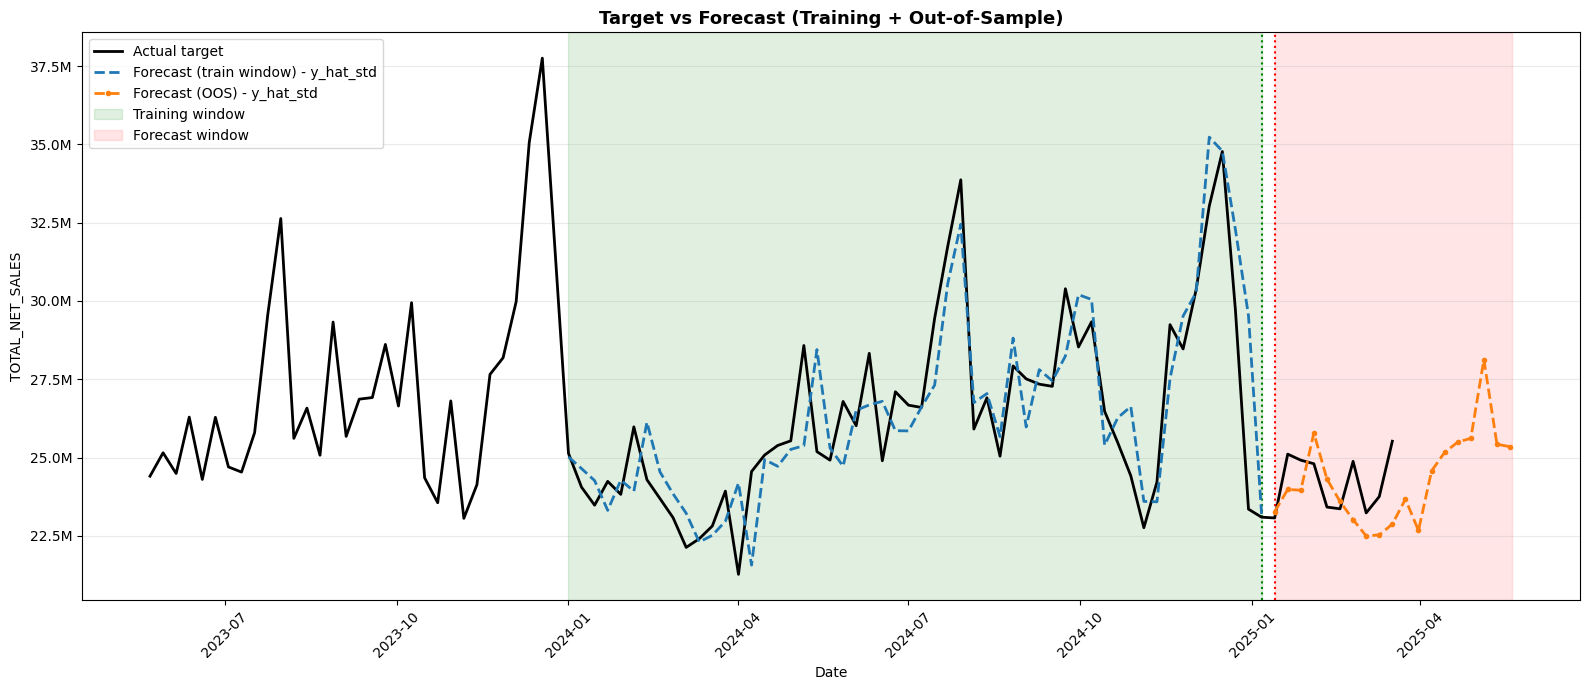

In [234]:
# Aggregate actual target over time
actual_agg = (
    df.groupby("ds", as_index=False)[y]
    .sum()
    .sort_values("ds")
)

# Pick forecast column (best model if available, otherwise first y_hat_*)
if "best_model_name" in globals():
    forecast_col = best_model_name
else:
    forecast_candidates = [c for c in all_forecasts.columns if c.startswith("y_hat_")]
    if not forecast_candidates:
        raise ValueError("No forecast columns found in `all_forecasts`.")
    forecast_col = forecast_candidates[0]

# Aggregate forecast over time
forecast_agg = (
    all_forecasts.groupby("ds", as_index=False)[forecast_col]
    .sum()
    .sort_values("ds")
    .rename(columns={forecast_col: "forecast"})
)

# Split forecast into in-sample (training window) and OOS
fcst_in = forecast_agg[(forecast_agg["ds"] >= training_start_date) & (forecast_agg["ds"] <= training_end_date)]
fcst_oos = forecast_agg[(forecast_agg["ds"] >= forecast_start_date) & (forecast_agg["ds"] <= forecast_end_date)]

# Plot
fig, ax = plt.subplots(figsize=(16, 7))

# Actual target
ax.plot(
    actual_agg["ds"], actual_agg[y],
    color="black", linewidth=2, label="Actual target", zorder=3
)

# Forecast in training window
if len(fcst_in) > 0:
    ax.plot(
        fcst_in["ds"], fcst_in["forecast"],
        color="tab:blue", linestyle="--", linewidth=2, label=f"Forecast (train window) - {forecast_col}", zorder=4
    )

# Forecast OOS
if len(fcst_oos) > 0:
    ax.plot(
        fcst_oos["ds"], fcst_oos["forecast"],
        color="tab:orange", linestyle="--", marker="o", markersize=3, linewidth=2,
        label=f"Forecast (OOS) - {forecast_col}", zorder=5
    )

# Windows
ax.axvspan(training_start_date, training_end_date, color="green", alpha=0.12, label="Training window")
ax.axvspan(forecast_start_date, forecast_end_date, color="red", alpha=0.10, label="Forecast window")
ax.axvline(training_end_date, color="green", linestyle=":", linewidth=1.5)
ax.axvline(forecast_start_date, color="red", linestyle=":", linewidth=1.5)

ax.set_title("Target vs Forecast (Training + Out-of-Sample)", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel(y)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.xticks(rotation=45)
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Train by Profile-Cluster

Train a separate model for each `profile_cluster` group. The `profile_cluster` variable is derived as:
- For **regular** profiles: use the `cluster` label (from notebook 04 Clustering)
- For all other profiles (intermittent, erratic, lumpy, etc.): use the `profile` label (from notebook 04 Profiling)

This allows regular series to be further segmented by their profile_cluster assignment, using their specific features from notebook 05 Feature Engineering, while non-regular profiles are trained separately for each profile group.

In [241]:
# Train a separate model for each profile_cluster group
profile_cluster_groups = df['profile_cluster'].unique()
print(f"Training models for {len(profile_cluster_groups)} profile_cluster groups: {sorted(profile_cluster_groups)}\n")

# End any stale MLflow run from previous cells
mlflow.end_run()

all_group_forecasts = []

for group in sorted(profile_cluster_groups):
    # Load data from Lakehouse table
    FEATURE_TABLE_NAME = "df_features_cluster_" + str(group)
    try:
        df_features_cluster = spark.read.table(f'{LAKEHOUSE_NAME}.{FEATURE_TABLE_NAME}').toPandas()
    except:
        print("❌ Failed to load data from Lakehouse table. Loading from local parquet file.")
        df_features_cluster = pd.read_parquet(f"{root_path}/data/{FEATURE_TABLE_NAME}.parquet")
    print(f"✅ Loaded {len(df_features_cluster)} rows, columns: {df_features_cluster.columns.tolist()}")

    # Use all rows from the cluster file
    df_group = df_features_cluster.copy()

    # Drop pre-computed lag/rolling features (MLForecast generates its own)
    lag_rolling_to_drop = [c for c in df_group.columns if c.startswith("lag") or c.startswith("rolling_")]
    if lag_rolling_to_drop:
        df_group = df_group.drop(columns=lag_rolling_to_drop)
        print(f"  Dropped {len(lag_rolling_to_drop)} pre-computed lag/rolling columns")

    # Ensure date column is datetime
    df_group['ds'] = pd.to_datetime(df_group['ds'])

    # Validate: target column must exist
    if y not in df_group.columns:
        print(f"⚠️ Target column '{y}' not in df_group. Merging from main df...")
        # Get IDs in this group and merge target from main df
        group_ids = df_group[unique_id].unique()
        target_data = df[df[unique_id].isin(group_ids)][[unique_id, 'ds', y]].copy()
        target_data['ds'] = pd.to_datetime(target_data['ds'])
        df_group = df_group.merge(target_data, on=[unique_id, 'ds'], how='left')
        print(f"  After merge: {len(df_group)} rows, target NaN count: {df_group[y].isna().sum()}")

    # Validate: check date range
    min_date = df_group['ds'].min()
    max_date = df_group['ds'].max()
    print(f"  Date range in df_group: {min_date.date()} to {max_date.date()}")

    # Filter eval_dates to only those where we have preceding training data
    group_eval_dates = [d for d in eval_dates if pd.to_datetime(d) > min_date]
    if len(group_eval_dates) < len(eval_dates):
        print(f"  ⚠️ Skipped {len(eval_dates) - len(group_eval_dates)} eval_dates (no training data before them)")
    if not group_eval_dates:
        print(f"  ❌ No valid eval_dates for group {group} — skipping")
        continue

    n_series = df_group[unique_id].nunique()
    print(f"\n{'='*60}")
    print(f"Training group: {group} ({n_series} series, {len(df_group)} rows)")
    print(f"{'='*60}")
    
    if len(df_group) == 0:
        print(f"Skipping group '{group}': no data")
        continue
    
    # Determine static features available for this group
    group_static = [f for f in static_cols if f in df_group.columns and f != 'profile_cluster']
    
    # Determine feature columns for this group (exclude target, id, date)
    group_feature_cols = [c for c in feature_cols if c in df_group.columns]
    
    try:
        with mlflow.start_run(run_name=f"profile_cluster_{group}", nested=False,
                              tags={"profile_cluster": str(group), "n_series": str(n_series)}):
            group_forecasts = rolling_train_and_predict_with_transform_oos(
                df_group,
                group_static,
                group_feature_cols,
                group_eval_dates,
                training_end_date,
                forecast_end_date,   
                mlf_date_features=date_features,
                lags=[1, 2],
                freq=frequency,
                id_col=unique_id,
                ds_col='ds',
                y_col=y,
            )
            group_forecasts['profile_cluster'] = group
            all_group_forecasts.append(group_forecasts)
            print(f"✅ Group '{group}': {len(group_forecasts)} forecast rows")
    except Exception as e:
        import traceback
        print(f"❌ Group '{group}' failed: {type(e).__name__}: {e}")
        traceback.print_exc()

# Combine all group forecasts
if all_group_forecasts:
    all_forecasts_by_group = pd.concat(all_group_forecasts, ignore_index=True)
    print(f"\n{'='*60}")
    print(f"Combined forecasts: {len(all_forecasts_by_group)} rows across {all_forecasts_by_group['profile_cluster'].nunique()} groups")
    print(f"{'='*60}")
else:
    raise ValueError("No forecasts were generated for any profile_cluster group.")

Training models for 2 profile_cluster groups: [0, 1]

❌ Failed to load data from Lakehouse table. Loading from local parquet file.
✅ Loaded 3360 rows, columns: ['STORE_LOCATION_ID', 'ds', 'TOTAL_NET_SALES', 'STORE_SELLING_AREA_SQFT', 'NEARBY_COMPETITOR_STORE_COUNT', 'COMPETITOR_PREMIUM_A_PRESENT', 'COMPETITOR_DISCOUNT_A_PRESENT', 'COMPETITOR_WAREHOUSE_A_PRESENT', 'COMPETITOR_PREMIUM_B_PRESENT', 'COMPETITOR_DISCOUNT_B_PRESENT', 'HAS_COMPETITOR_IN_TRADE_AREA', 'STORE_COUNT_IN_POSTAL_AREA', 'IS_SOLE_STORE_IN_POSTAL_AREA', 'MARKET_SHARE_AREA_POSTAL', 'BASELINE_WEEKLY_SALES', 'STORE_ARCHETYPE', 'REGION', 'profile_cluster', 'lag1', 'lag2', 'rolling_mean_lag1_window_size3', 'rolling_std_lag1_window_size3', 'rolling_mean_lag2_window_size6', 'rolling_std_lag2_window_size6', 'year', 'month', 'week']
  Dropped 6 pre-computed lag/rolling columns
  Date range in df_group: 2023-05-22 to 2025-03-17

Training group: 0 (35 series, 3360 rows)
Evaluation dates: ['2024-01-01', '2024-01-08', '2024-01-15', 

### Compute metrics per profile_cluster group

In [242]:
group_metrics_list = []

for group in all_forecasts_by_group['profile_cluster'].unique():
    group_fcst = all_forecasts_by_group[all_forecasts_by_group['profile_cluster'] == group]
    group_metrics = compute_all_metrics(
        rolling_results=group_fcst.drop(columns=['profile_cluster']),
        df=df,
        id_col=unique_id,
        ds_col='ds',
        y_col=y,
    )
    group_metrics['profile_cluster'] = group
    group_metrics_list.append(group_metrics)

metrics_by_group = pd.concat(group_metrics_list, ignore_index=True)

# Also compute overall metrics
overall_metrics = compute_all_metrics(
    rolling_results=all_forecasts_by_group.drop(columns=['profile_cluster']),
    df=df,
    id_col=unique_id,
    ds_col='ds',
    y_col=y,
)
overall_metrics['profile_cluster'] = 'OVERALL'

metrics_by_group = pd.concat([metrics_by_group, overall_metrics], ignore_index=True)

print("=" * 60)
print("MODEL RESULTS BY PROFILE-CLUSTER GROUP")
print("=" * 60)
display(metrics_by_group.sort_values(['profile_cluster', selection_metric]))

MODEL RESULTS BY PROFILE-CLUSTER GROUP


,model,WMAPE,MAE,RMSE,profile_cluster
0,y_hat_identity,0.071637,29998.620621,37789.956406,0
1,y_hat_std,0.075649,31678.627324,40570.862314,0
2,y_hat_diff1,0.095491,39988.008471,51619.169313,0
3,y_hat_std,0.050563,38267.646453,49034.975013,1
4,y_hat_identity,0.051712,39137.469195,50949.499300,1
5,y_hat_diff1,0.061995,46919.649409,62526.402937,1
6,y_hat_identity,0.062940,32740.275193,42171.222502,OVERALL
7,y_hat_std,0.064699,33655.333063,43284.235474,OVERALL
8,y_hat_diff1,0.080871,42067.500752,55118.439452,OVERALL


### Feature importance analysis for the best model per cluster

Best model per cluster:


,profile_cluster,model,MAE
0,0,y_hat_identity,29998.620621
1,1,y_hat_std,38267.646453



Cluster 0: retraining with transform='identity' to extract feature importances
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 744
[LightGBM] [Info] Number of data points in the train set: 2905, number of used features: 18
[LightGBM] [Info] Start training from score 432276.470923
  Top 5 features: ['week', 'lag1', 'lag2', 'month', 'STORE_SELLING_AREA_SQFT']

Cluster 1: retraining with transform='std' to extract feature importances
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 672
[LightGBM] [Info] Number of data points in the train set: 1245, number of used features: 18
[LightGBM] [Info] Start training from score 0.011703
  Top 5 features:

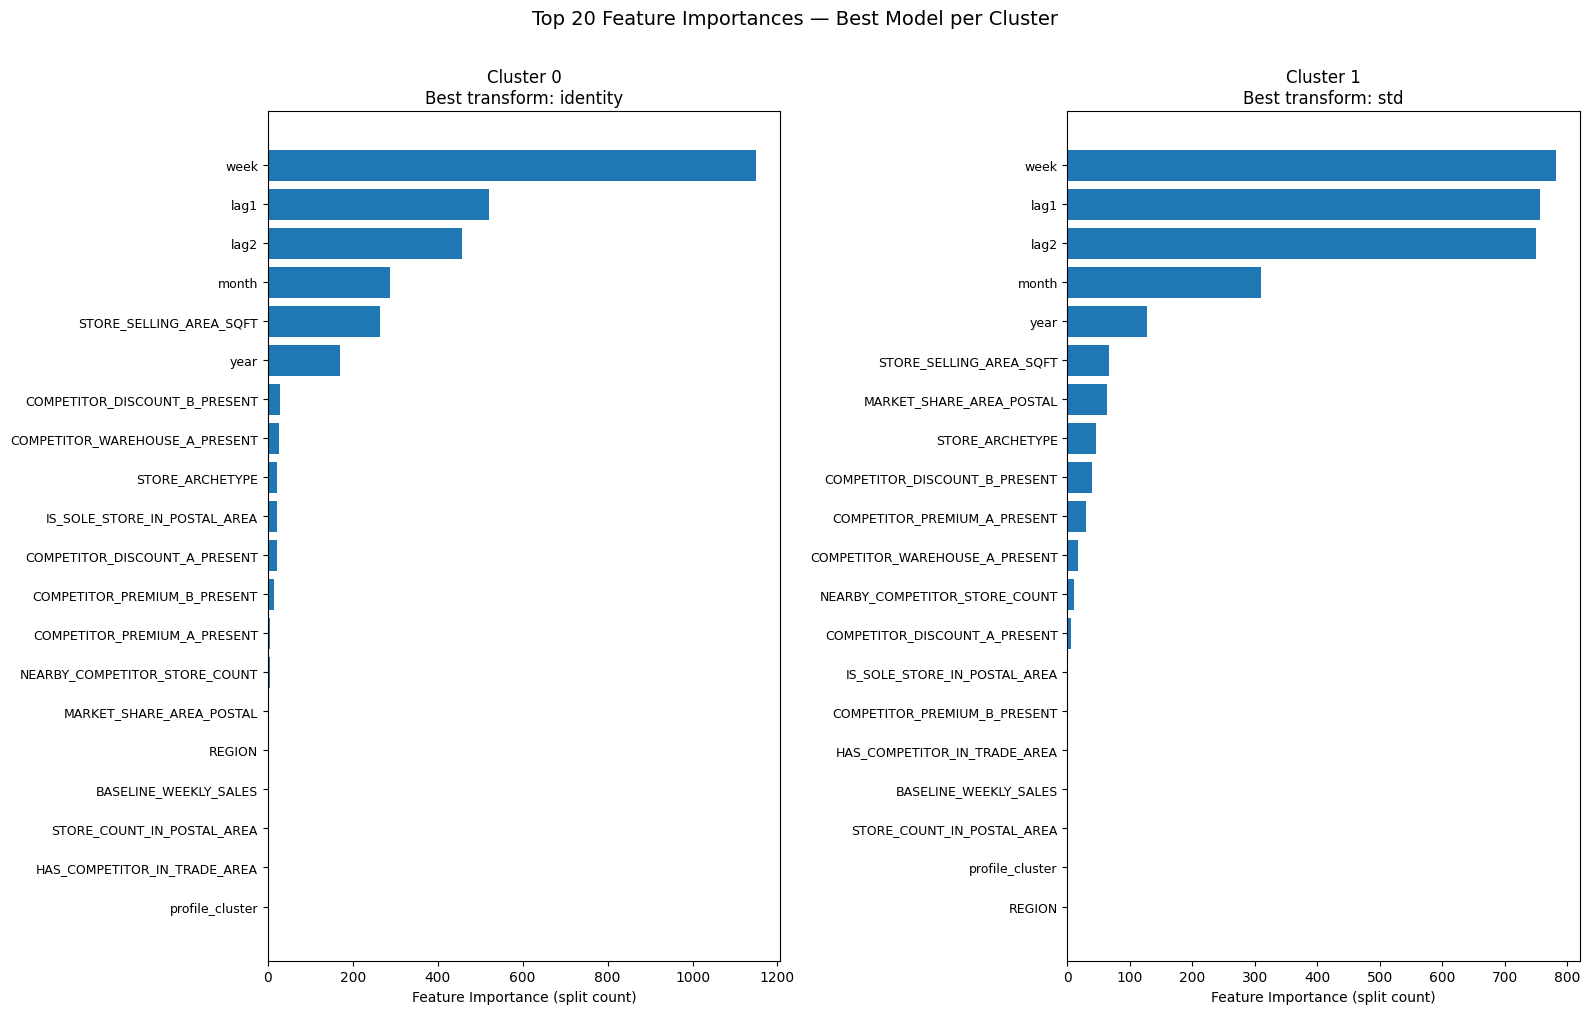

In [243]:
# 1. Identify the best transform per cluster from metrics_by_group
top_n = 20

transform_configs = {
    "identity": [],
    "std": [LocalStandardScaler()],
    "diff1": [Differences([1])],
}

best_per_cluster = (
    metrics_by_group[metrics_by_group['profile_cluster'] != 'OVERALL']
    .sort_values(selection_metric)
    .groupby('profile_cluster')
    .first()
    .reset_index()
)

print("Best model per cluster:")
display(best_per_cluster[['profile_cluster', 'model', selection_metric]])

# 2. Retrain best model per cluster on full training data and extract feature importances
importance_frames = []

for _, row in best_per_cluster.iterrows():
    cluster = row['profile_cluster']
    best_model_col = row['model']  # e.g. "y_hat_std"
    transform_name = best_model_col.replace("y_hat_", "")
    tfs = transform_configs[transform_name]

    print(f"\nCluster {cluster}: retraining with transform='{transform_name}' to extract feature importances")

    # Filter data for this cluster
    group_ids = df.loc[df['profile_cluster'] == cluster, unique_id].unique()
    df_cluster = df[df[unique_id].isin(group_ids)].copy()
    train_cluster = df_cluster[df_cluster['ds'] < training_end_date].copy()

    group_static = [f for f in static_cols if f in df_cluster.columns and f != 'profile_cluster']

    base_model = LGBMRegressor(random_state=42)
    mlf_tmp = MLForecast(
        models=[base_model],
        freq=frequency,
        lags=[1, 2],
        date_features=date_features,
        target_transforms=tfs,
    )
    mlf_tmp.fit(
        train_cluster,
        id_col=unique_id,
        time_col='ds',
        target_col=y,
        static_features=group_static,
    )

    booster = mlf_tmp.models_['LGBMRegressor']
    feat_names = booster.feature_name_
    feat_importances = booster.feature_importances_

    fi = pd.DataFrame({
        'feature': feat_names,
        'importance': feat_importances,
        'profile_cluster': cluster,
        'transform': transform_name,
    }).sort_values('importance', ascending=False)

    importance_frames.append(fi)
    print(f"  Top 5 features: {fi.head(5)['feature'].tolist()}")

all_importances = pd.concat(importance_frames, ignore_index=True)

# 3. Plot top-N feature importances per cluster
n_clusters = best_per_cluster.shape[0]
fig, axes = plt.subplots(1, n_clusters, figsize=(8 * n_clusters, 10), sharey=False)
if n_clusters == 1:
    axes = [axes]

for ax, (cluster, grp) in zip(axes, all_importances.groupby('profile_cluster')):
    top = grp.nlargest(top_n, 'importance')
    transform_name = top['transform'].iloc[0]
    ax.barh(top['feature'][::-1], top['importance'][::-1])
    ax.set_xlabel('Feature Importance (split count)')
    ax.set_title(f'Cluster {cluster}\nBest transform: {transform_name}')
    ax.tick_params(axis='y', labelsize=9)

fig.suptitle(f'Top {top_n} Feature Importances — Best Model per Cluster', fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### Out-of-sample forecast chart: actuals vs best model per cluster

C:\Users\mabellani\AppData\Local\Temp\ipykernel_24824\1791959634.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['profile_cluster', 'ds'])[y]


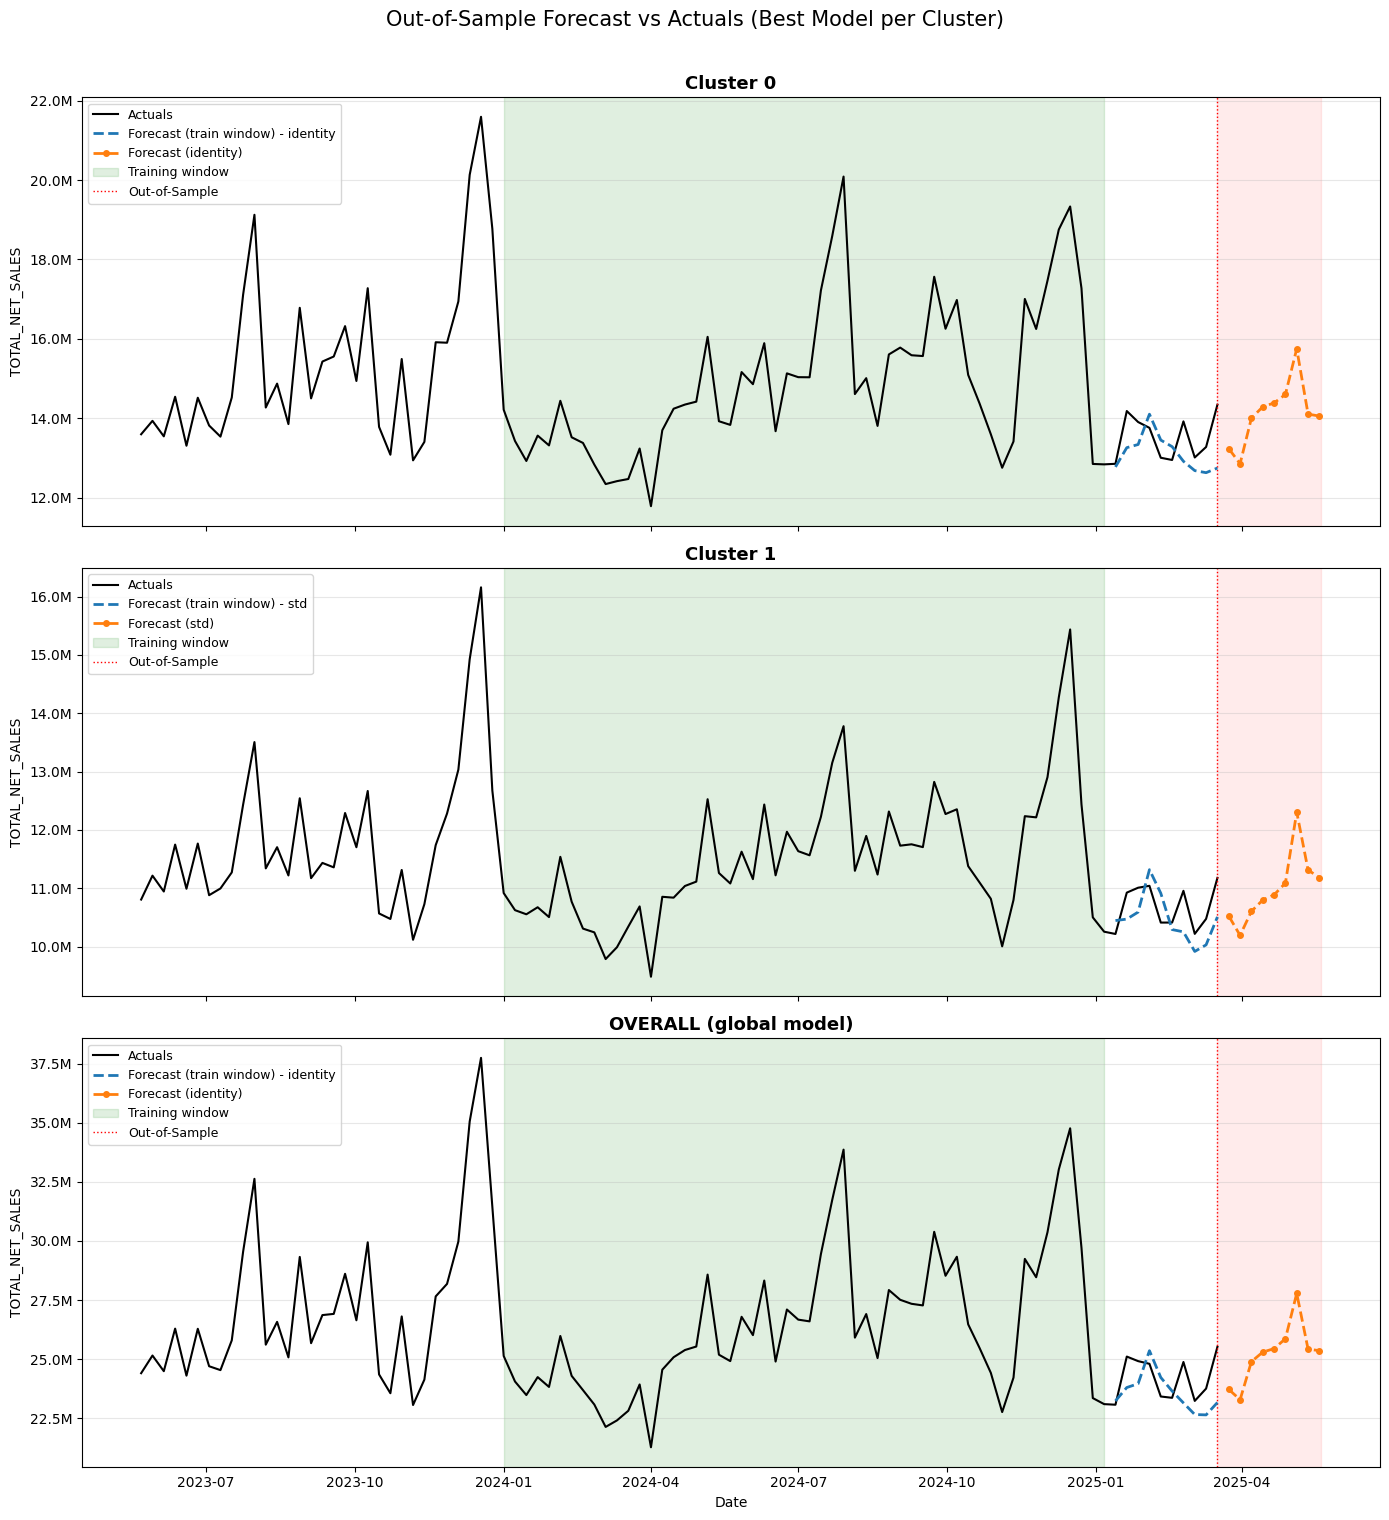

In [244]:
# For each cluster, pick the best transform and plot aggregated actuals vs forecast

# Identify best model column per cluster
best_model_per_cluster = (
    metrics_by_group[metrics_by_group['profile_cluster'] != 'OVERALL']
    .sort_values(selection_metric)
    .groupby('profile_cluster')
    .first()
    .reset_index()[['profile_cluster', 'model']]
)

# Prepare actuals aggregated by cluster and date
actuals_by_cluster = (
    df.merge(df[[unique_id, 'profile_cluster']].drop_duplicates(), on=unique_id, how='left', suffixes=('', '_dup'))
)
# Use the non-duplicate profile_cluster column
if 'profile_cluster_dup' in actuals_by_cluster.columns:
    actuals_by_cluster = actuals_by_cluster.drop(columns=['profile_cluster_dup'])

actuals_agg = (
    actuals_by_cluster
    .groupby(['profile_cluster', 'ds'])[y]
    .sum()
    .reset_index()
)

# Prepare forecasts aggregated by cluster and date, using the best model for each cluster
forecast_rows = []
for _, brow in best_model_per_cluster.iterrows():
    cl = brow['profile_cluster']
    model_col = brow['model']
    cl_fcst = all_forecasts_by_group[all_forecasts_by_group['profile_cluster'] == cl].copy()
    # Filter to OOS dates only
    cl_fcst = cl_fcst[cl_fcst['ds'] > training_end_date]
    agg = cl_fcst.groupby('ds')[model_col].sum().reset_index()
    agg.rename(columns={model_col: 'forecast'}, inplace=True)
    agg['profile_cluster'] = cl
    agg['model'] = model_col.replace('y_hat_', '')
    forecast_rows.append(agg)

forecast_agg = pd.concat(forecast_rows, ignore_index=True)

# Also build an "OVERALL" aggregation
overall_best = (
    metrics_by_group[metrics_by_group['profile_cluster'] == 'OVERALL']
    .sort_values(selection_metric)
    .iloc[0]
)
overall_model_col = overall_best['model']
overall_fcst = all_forecasts_by_group[all_forecasts_by_group['ds'] > training_end_date].copy()
overall_agg = overall_fcst.groupby('ds')[overall_model_col].sum().reset_index()
overall_agg.rename(columns={overall_model_col: 'forecast'}, inplace=True)
overall_agg['profile_cluster'] = 'OVERALL'
overall_agg['model'] = overall_model_col.replace('y_hat_', '')

forecast_agg = pd.concat([forecast_agg, overall_agg], ignore_index=True)

# Overall actuals
overall_actuals = df.groupby('ds')[y].sum().reset_index()
overall_actuals['profile_cluster'] = 'OVERALL'
actuals_agg = pd.concat([actuals_agg, overall_actuals], ignore_index=True)

# Plot
clusters_to_plot = sorted(best_model_per_cluster['profile_cluster'].tolist()) + ['OVERALL']
n_plots = len(clusters_to_plot)
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 5 * n_plots), sharex=True)
if n_plots == 1:
    axes = [axes]

for ax, cl in zip(axes, clusters_to_plot):
    # Actuals
    act = actuals_agg[actuals_agg['profile_cluster'] == cl].sort_values('ds')
    ax.plot(act['ds'], act[y], color='black', linewidth=1.5, label='Actuals', zorder=2)
    
    max_actual_date = act['ds'].max()
    
    # Forecast (in-sample dashed)
    fc_in = forecast_agg[
        (forecast_agg['profile_cluster'] == cl) &
        (forecast_agg['ds'] <= max_actual_date)
    ].sort_values('ds')
    if len(fc_in) > 0:
        model_label = fc_in['model'].iloc[0]
        ax.plot(fc_in['ds'], fc_in['forecast'], color='tab:blue', linewidth=2,
                linestyle='--', label=f'Forecast (train window) - {model_label}', zorder=3)

    # Forecast (OOS only)
    fc = forecast_agg[
        (forecast_agg['profile_cluster'] == cl) &
        (forecast_agg['ds'] > max_actual_date)
    ].sort_values('ds')
    if len(fc) > 0:
        model_label = fc['model'].iloc[0]
        ax.plot(fc['ds'], fc['forecast'], color='tab:orange', linewidth=2,
                linestyle='--', marker='o', markersize=4, label=f'Forecast ({model_label})', zorder=3)

    # Share Training region
    ax.axvspan(training_start_date, training_end_date, color='green', alpha=0.12, label='Training window')
    
    # Shade OOS region
    ax.axvline(x=max_actual_date, color='red', linestyle=':', linewidth=1, label='Out-of-Sample')
    ax.axvspan(max_actual_date, forecast_end_date, alpha=0.08, color='red')

    title = f'Cluster {cl}' if cl != 'OVERALL' else 'OVERALL (global model)'
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(y)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

axes[-1].set_xlabel('Date')

fig.suptitle('Out-of-Sample Forecast vs Actuals (Best Model per Cluster)', fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

In [245]:
# Summary of key results
print("=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

# Overall model metrics
print("\n--- Overall (Global) Model Metrics ---")
display(metrics_df.sort_values(selection_metric))

print(f"\nBest overall model: {best_model_name}  (transform: {best_transform})")
print(f"Selection metric: {selection_metric}")

# Per-cluster model metrics
print("\n--- Per-Cluster Model Metrics ---")
display(metrics_by_group.sort_values(['profile_cluster', selection_metric]))

# Best model per cluster
print("\n--- Best Model per Cluster ---")
for _, row in best_per_cluster.iterrows():
    cl = row['profile_cluster']
    model = row['model']
    metric_val = row[selection_metric]
    print(f"  Cluster {cl}: {model}  ({selection_metric} = {metric_val:,.0f})")

# Date ranges
print(f"\nTraining period:  {training_start_date.date()} to {training_end_date.date()}")
print(f"Forecast period:  {forecast_start_date.date()} to {forecast_end_date.date()}")
print(f"Frequency: {frequency}")

RESULTS SUMMARY

--- Overall (Global) Model Metrics ---


,model,WMAPE,MAE,RMSE
1,y_hat_std,0.063503,33033.061900,42523.999543
0,y_hat_identity,0.063639,33103.796482,42001.995189
2,y_hat_diff1,0.078560,40865.338420,52909.888186



Best overall model: y_hat_std  (transform: std)
Selection metric: MAE

--- Per-Cluster Model Metrics ---


,model,WMAPE,MAE,RMSE,profile_cluster
0,y_hat_identity,0.071637,29998.620621,37789.956406,0
1,y_hat_std,0.075649,31678.627324,40570.862314,0
2,y_hat_diff1,0.095491,39988.008471,51619.169313,0
3,y_hat_std,0.050563,38267.646453,49034.975013,1
4,y_hat_identity,0.051712,39137.469195,50949.499300,1
5,y_hat_diff1,0.061995,46919.649409,62526.402937,1
6,y_hat_identity,0.062940,32740.275193,42171.222502,OVERALL
7,y_hat_std,0.064699,33655.333063,43284.235474,OVERALL
8,y_hat_diff1,0.080871,42067.500752,55118.439452,OVERALL



--- Best Model per Cluster ---
  Cluster 0: y_hat_identity  (MAE = 29,999)
  Cluster 1: y_hat_std  (MAE = 38,268)

Training period:  2024-01-01 to 2025-01-06
Forecast period:  2025-01-13 to 2025-05-20
Frequency: W-MON


In [246]:
# Per-cluster metrics (compact)
for cl in sorted(metrics_by_group['profile_cluster'].unique(), key=str):
    subset = metrics_by_group[metrics_by_group['profile_cluster'] == cl].sort_values(selection_metric)
    print(f"\nCluster {cl}:")
    for _, r in subset.iterrows():
        print(f"  {r['model']:20s}  WMAPE={r['WMAPE']*100:.2f}%  MAE={r['MAE']:>10,.0f}  RMSE={r['RMSE']:>10,.0f}")


Cluster 0:
  y_hat_identity        WMAPE=7.16%  MAE=    29,999  RMSE=    37,790
  y_hat_std             WMAPE=7.56%  MAE=    31,679  RMSE=    40,571
  y_hat_diff1           WMAPE=9.55%  MAE=    39,988  RMSE=    51,619

Cluster 1:
  y_hat_std             WMAPE=5.06%  MAE=    38,268  RMSE=    49,035
  y_hat_identity        WMAPE=5.17%  MAE=    39,137  RMSE=    50,949
  y_hat_diff1           WMAPE=6.20%  MAE=    46,920  RMSE=    62,526

Cluster OVERALL:
  y_hat_identity        WMAPE=6.29%  MAE=    32,740  RMSE=    42,171
  y_hat_std             WMAPE=6.47%  MAE=    33,655  RMSE=    43,284
  y_hat_diff1           WMAPE=8.09%  MAE=    42,068  RMSE=    55,118
